# Angular Power Spectra: Galaxy Auto & CMB Lensing × Galaxy Cross
### General Relativity vs f(R) Modified Gravity
---

This notebook computes two angular power spectra on the sky:

- $C_\ell^{gg}$: the **galaxy angular auto-spectrum**, tracing the projected clustering of galaxies.
- $C_\ell^{\kappa g}$: the **CMB lensing × galaxy cross-spectrum**, correlating the CMB lensing convergence $\kappa$ with the galaxy density field.

Both are computed within the **Limber approximation**, which reduces a 3D integral over the power spectrum $P(k)$ to a 1D line-of-sight integral using the correspondence $k \approx (\ell + \tfrac{1}{2})/\chi(z)$.

The spectra are evaluated for:
1. **General Relativity (GR)** — using the BACCO emulator for the nonlinear matter power spectrum.
2. **f(R) modified gravity** — using the EMANTIS emulator to apply a scale- and redshift-dependent boost $B(k,z) = P^{f(R)}/P^{GR}$ on top of BACCO.

The formalism (kernels, Limber integrals, bias and magnification treatment) follows [Bianchini et al. (2015)](https://arxiv.org/pdf/1410.4502), [Karim et al. (2025)](https://arxiv.org/pdf/2408.15909), and [Lahav & Suto (2004)](https://arxiv.org/pdf/astro-ph/0310642).

**How to run:** Execute cells top-to-bottom. Every function is verified immediately after definition. The final cell runs a comprehensive validation suite.


In [1]:
pip install -q baccoemu emantis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 849.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 3.8 MB/s eta 0:00:00


## 1. Imports & Environment Setup

The notebook depends on the following packages:

| Package | Role |
|---|---|
| `numpy` / `scipy` | Array operations, numerical integration (`quad`, `simpson`), and interpolation |
| `matplotlib` | All plots |
| `baccoemu` | Neural-network emulator for the nonlinear GR matter power spectrum $P(k,z)$ |
| `emantis` | Neural-network emulator for the f(R) gravity boost factor $B(k,z)$ |

Verbose output from the emulators is suppressed globally so that only our own print statements appear.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import os
from contextlib import redirect_stdout, redirect_stderr
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad

import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

# Verify all imports
print("Import check:")
for name, mod in [("numpy", np), ("matplotlib", plt), ("baccoemu", baccoemu),
                  ("scipy.integrate.quad", quad)]:
    print(f"  ✓  {name}")
print(f"  numpy version : {np.__version__}")


Import check:
  ✓  numpy
  ✓  matplotlib
  ✓  baccoemu
  ✓  scipy.integrate.quad
  numpy version : 2.0.2


## 2. Configuration

All run parameters are centralised in the `Config` class. Edit values here rather than hunting through the code.

**Cosmological parameters** follow a flat $\Lambda$CDM baseline close to the Planck 2018 best-fit values ($\Omega_m = 0.315$, $h = 0.67$, $\sigma_8 = 0.83$). Setting $w_0 = -1$, $w_a = 0$ and $M_\nu = 0$ reduces the model to standard $\Lambda$CDM.

**Redshift grid** ($z \in [0.01, 1.5]$, $N_z = 500$): the lower limit avoids the $\chi \to 0$ singularity; the upper limit covers the bulk of the galaxy redshift distribution.

**Multipole range** ($\ell \in [10, 2000]$, $N_\ell = 50$, log-spaced): large-scale modes ($\ell \lesssim 10$) violate the Limber approximation; small-scale modes ($\ell \gtrsim 2000$) enter the deeply nonlinear regime where the emulator accuracy degrades.

**Galaxy bias** $b_0 = 2.0$ sets the amplitude of the scale-independent linear bias at $z=0$. The magnification bias parameter $\alpha = 2.225$ controls the contribution of flux-limited survey magnification to the observed galaxy density (Karim et al. 2025).

**f(R) parameters**: `FR_VALUES = [4, 5, 6]` correspond to $\log_{10}|f_{R0}| = -4, -5, -6$. Smaller values of $\log_{10}|f_{R0}|$ mean a larger deviation from GR and a stronger enhancement of the matter power spectrum.

**k-grid safety factors**: after mapping $k = (\ell+\tfrac{1}{2})/\chi(z)$, some $k$ values may fall outside the emulator training range. The safety factors clip them inward by 10% to avoid extrapolation artefacts.


In [3]:
class Config:
    # ── Cosmological Parameters ────────────────────────────────────────────────
    COSMO_PARAMS = {
        "Omega_m":  0.315,   # Total matter density parameter
        "Omega_b":  0.05,    # Baryon density parameter
        "h":        0.67,    # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s":      0.96,    # Primordial scalar spectral index
        "sigma8":   0.83,    # RMS matter fluctuation amplitude at 8 Mpc/h
        "M_nu":     0.0,     # Sum of neutrino masses (eV)
        "w0":      -1.0,     # Dark energy equation of state today
        "wa":       0.0,     # Time variation of dark energy equation of state
        "aexp":     1.0      # Scale factor (1.0 = present day)
    }
    TRANSFER_FUNCTION = "boltzmann_camb"
    c = 299792.458           # Speed of light [km/s]

    # ── Redshift Grid ──────────────────────────────────────────────────────────
    Z_MIN     = 0.01
    Z_MAX     = 1.5
    N_Z       = 500
    Z0_GALAXY = 0.3          # Characteristic galaxy redshift

    # ── Multipole Range ────────────────────────────────────────────────────────
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL   = 50

    # ── Galaxy & Magnification Bias ───────────────────────────────────────────
    BIAS_B0 = 2.0
    alpha   = 2.225          # Magnification bias (Karim et al.)

    # ── f(R) Parameters ───────────────────────────────────────────────────────
    FR_VALUES = [4, 5, 6]    # log10|fR0| values

    # ── BACCO k-grid ──────────────────────────────────────────────────────────
    BACCO_K_MIN     = -2
    BACCO_K_MAX     = None   # None → use emulator maximum
    BACCO_N_K       = 200
    EMANTIS_VERBOSE = False

    FIGURE_SIZE      = (14, 10)
    K_MIN_SAFETY     = 1.1
    K_MAX_SAFETY     = 0.9
    K_CLIP_THRESHOLD = 0.05

# Convenience aliases used throughout
H0        = Config.COSMO_PARAMS["h"] * 100.0
Om_m      = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m       # flat LCDM

# Print summary
print("Configuration loaded:")
print(f"  Omega_m = {Config.COSMO_PARAMS['Omega_m']},  h = {Config.COSMO_PARAMS['h']},  "
      f"sigma8 = {Config.COSMO_PARAMS['sigma8']}")
print(f"  w0 = {Config.COSMO_PARAMS['w0']},  wa = {Config.COSMO_PARAMS['wa']},  "
      f"M_nu = {Config.COSMO_PARAMS['M_nu']} eV")
print(f"  Redshift range : z in [{Config.Z_MIN}, {Config.Z_MAX}]  (N_z = {Config.N_Z})")
print(f"  Multipole range: ell in [{Config.ELL_MIN}, {Config.ELL_MAX}]  (N_ell = {Config.N_ELL})")
print(f"  Galaxy bias b0 = {Config.BIAS_B0},  magnification alpha = {Config.alpha}")
print(f"  f(R) log10|fR0| values: {Config.FR_VALUES}")
print(f"  H0 = {H0:.1f} km/s/Mpc,  Om_lambda = {Om_lambda:.3f} (flat LCDM)")


Configuration loaded:
  Omega_m = 0.315,  h = 0.67,  sigma8 = 0.83
  w0 = -1.0,  wa = 0.0,  M_nu = 0.0 eV
  Redshift range : z in [0.01, 1.5]  (N_z = 500)
  Multipole range: ell in [10, 2000]  (N_ell = 50)
  Galaxy bias b0 = 2.0,  magnification alpha = 2.225
  f(R) log10|fR0| values: [4, 5, 6]
  H0 = 67.0 km/s/Mpc,  Om_lambda = 0.685 (flat LCDM)


## 3. Core Cosmological Functions

This section builds the cosmological machinery needed to construct the Limber line-of-sight kernels. The functions are defined in dependency order — each one is verified with a plot and assertion immediately after definition.

The full dependency chain is:

$$H(z) \;\to\; \chi(z) \;\to\; \Omega(z),\,\lambda(z),\,g(z) \;\to\; D(z) \;\to\; b(z),\;W^\kappa(z),\;W^g(z)$$


### 3.1 Hubble Function $H(z)$

For a flat universe with a cosmological constant:

$$H(z) = H_0 \sqrt{\Omega_m(1+z)^3 + (1-\Omega_m-\Omega_\Lambda)(1+z)^2 + \Omega_\Lambda}$$

The middle term vanishes for a spatially flat model ($\Omega_k = 0$, so $\Omega_\Lambda = 1 - \Omega_m$). $H(z)$ enters every subsequent integral via $c/H(z)$, which converts a redshift interval $dz$ into a comoving length element. It also appears in the kernels $W^\kappa$ and $W^g$ through the 1/$H(z)$ prefactor needed for the $dz$-basis Limber integral.

*Reference: Lin et al. (2009), Eq. 1.*


H(z=0) = 67.00 km/s/Mpc  (expected = H0 = 67.00)


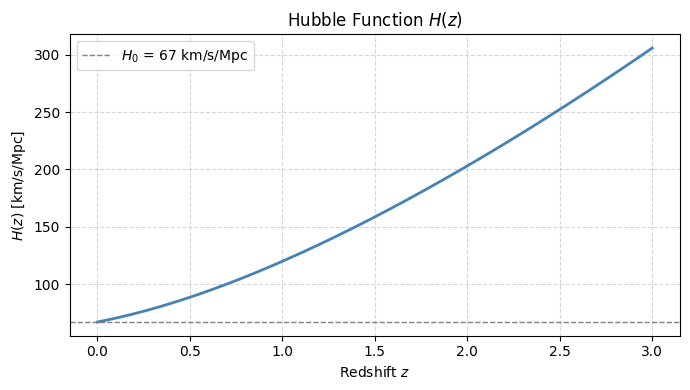

H(z=0.3) = 78.62,  H(z=1.0) = 119.95 km/s/Mpc


In [4]:
def hubble_function(z, H0, Om_m, Om_lambda):
    """H(z) for flat wCDM cosmology [km/s/Mpc]."""
    return H0 * np.sqrt(
        Om_m * (1 + z)**3
        + (1 - Om_m - Om_lambda) * (1 + z)**2
        + Om_lambda
    )

# ── Immediate verification ─────────────────────────────────────────────────────
H_z0 = hubble_function(0.0, H0, Om_m, Om_lambda)
print(f"H(z=0) = {H_z0:.2f} km/s/Mpc  (expected = H0 = {H0:.2f})")
assert abs(H_z0 - H0) < 1e-6, "H(z=0) must equal H0"

z_test = np.linspace(0.0, 3.0, 300)
H_test = hubble_function(z_test, H0, Om_m, Om_lambda)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_test, H_test, 'steelblue', lw=2)
ax.axhline(H0, color='gray', ls='--', lw=1, label=f'$H_0$ = {H0:.0f} km/s/Mpc')
ax.set(xlabel='Redshift $z$', ylabel='$H(z)$ [km/s/Mpc]', title='Hubble Function $H(z)$')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
print(f"H(z=0.3) = {hubble_function(0.3, H0, Om_m, Om_lambda):.2f},  "
      f"H(z=1.0) = {hubble_function(1.0, H0, Om_m, Om_lambda):.2f} km/s/Mpc")


### 3.2 Comoving Distance $\chi(z)$

$$\chi(z) = \int_0^z \frac{c}{H(z')}\,dz'$$

This is the cornerstone of the Limber approximation: the correspondence $k \approx (\ell+\tfrac{1}{2})/\chi(z)$ maps angular multipole $\ell$ to physical wavenumber $k$ at each redshift. $\chi(z)$ also appears in the geometric lensing prefactors $\chi(\chi_* - \chi)/\chi_*$ that weight the CMB lensing kernel.

Computed via `scipy.integrate.quad` for both scalar and array inputs. $\chi(z)$ must be strictly monotonically increasing — verified below.

*Reference: Lahav & Suto (2004), Eq. 146.*


chi(z -> 0)  = 0.4474 Mpc  (expected ~ 0)


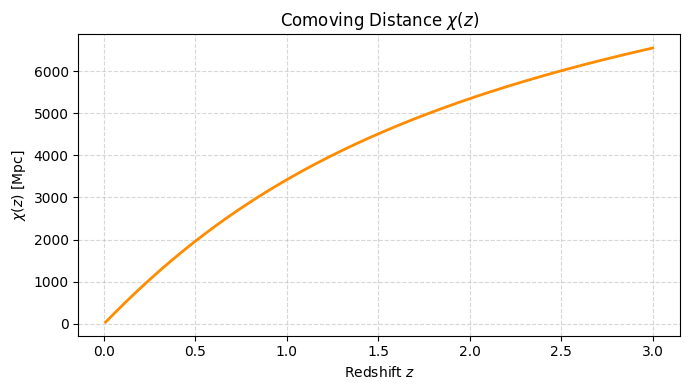

  chi(z=0.3) = 1243.8 Mpc
  chi(z=0.5) = 1963.0 Mpc
  chi(z=1.0) = 3421.6 Mpc
  chi(z=1.5) = 4508.9 Mpc
chi(z) is monotonically increasing: OK


In [5]:
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    """Comoving distance chi(z) [Mpc] via numerical quadrature."""
    def integrand(zp):
        return Config.c / hubble_function(zp, H0, Om_m, Om_lambda)
    if np.isscalar(z):
        return quad(integrand, 0, z)[0]
    return np.array([quad(integrand, 0, zv)[0] for zv in z])

# ── Immediate verification ─────────────────────────────────────────────────────
chi_near_zero = comoving_distance_proper(1e-4, H0, Om_m, Om_lambda)
print(f"chi(z -> 0)  = {chi_near_zero:.4f} Mpc  (expected ~ 0)")
assert chi_near_zero < 1.0, "chi(z~0) should be near zero"

z_test = np.linspace(0.01, 3.0, 200)
chi_test = comoving_distance_proper(z_test, H0, Om_m, Om_lambda)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_test, chi_test, 'darkorange', lw=2)
ax.set(xlabel='Redshift $z$', ylabel=r'$\chi(z)$ [Mpc]',
       title='Comoving Distance $\chi(z)$')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

for zv in [0.3, 0.5, 1.0, 1.5]:
    print(f"  chi(z={zv}) = {comoving_distance_proper(zv, H0, Om_m, Om_lambda):.1f} Mpc")
assert np.all(np.diff(chi_test) > 0), "chi(z) must be monotonically increasing"
print("chi(z) is monotonically increasing: OK")


### 3.3 Growth Function Helpers: $\Omega_m(z)$, $\Omega_\Lambda(z)$, and $g(z)$

These are intermediate quantities on the way to the linear growth factor $D(z)$.

**$\Omega_m(z)$** is the fractional matter density at redshift $z$. At high $z$ it approaches 1 (matter-dominated era); at $z=0$ it equals the input $\Omega_m$.

**$\Omega_\Lambda(z)$** is the fractional dark energy density. It decreases rapidly toward high $z$ because matter dilutes as $(1+z)^3$ while $\Lambda$ stays constant.

**$g(z)$** is the Carroll–Press–Turner (1992) fitting formula, an analytic approximation to the growth suppression factor relative to an Einstein–de Sitter universe. It is accurate to ~1% for typical $\Lambda$CDM cosmologies.

$$g(z) = \frac{5\Omega_m(z)/2}{\Omega_m(z)^{4/7} - \Omega_\Lambda(z) + \left[1+\Omega_m(z)/2\right]\left[1+\Omega_\Lambda(z)/70\right]}$$

*Reference: Lahav & Suto (2004), Eqs. 67–69.*


At z=0:  Omega_m(z=0) = 0.3150  (expected 0.315)
At z=0:  Omega_Lam(z=0) = 0.6850  (expected 0.6850)


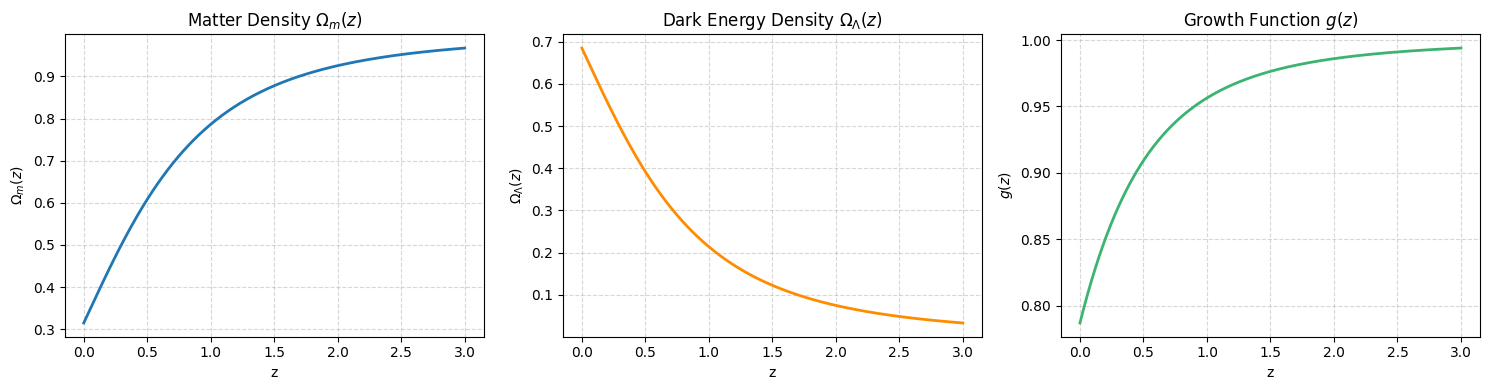

In [6]:
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    """Omega_m(z) — matter density parameter at redshift z."""
    den = Om_m*(1+z)**3 + (1-Om_m-Om_lambda)*(1+z)**2 + Om_lambda
    return Om_m * (1+z)**3 / den

def compute_lambda_z(z, H0, Om_m, Om_lambda):
    """Omega_Lambda(z) — dark energy density parameter at redshift z."""
    den = Om_m*(1+z)**3 + (1-Om_m-Om_lambda)*(1+z)**2 + Om_lambda
    return Om_lambda / den

def growth_function_g(z, H0, Om_m, Om_lambda):
    """Carroll-Press-Turner fitting formula for g(z) (Lahav 2004, Eq. 67)."""
    Oz = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lz = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Oz**(4/7) - lz + (1 + Oz/2)*(1 + lz/70)
    return (5 * Oz / 2) / den

# ── Immediate verification ─────────────────────────────────────────────────────
Oz_0  = compute_Omega_z(0.0, H0, Om_m, Om_lambda)
lz_0  = compute_lambda_z(0.0, H0, Om_m, Om_lambda)
print(f"At z=0:  Omega_m(z=0) = {Oz_0:.4f}  (expected {Om_m})")
print(f"At z=0:  Omega_Lam(z=0) = {lz_0:.4f}  (expected {Om_lambda:.4f})")
assert abs(Oz_0 - Om_m) < 1e-6 and abs(lz_0 - Om_lambda) < 1e-6

z_test = np.linspace(0.0, 3.0, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(z_test, [compute_Omega_z(z, H0, Om_m, Om_lambda) for z in z_test], lw=2)
axes[0].set(xlabel='z', ylabel=r'$\Omega_m(z)$', title=r'Matter Density $\Omega_m(z)$')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(z_test, [compute_lambda_z(z, H0, Om_m, Om_lambda) for z in z_test],
             color='darkorange', lw=2)
axes[1].set(xlabel='z', ylabel=r'$\Omega_\Lambda(z)$',
            title=r'Dark Energy Density $\Omega_\Lambda(z)$')
axes[1].grid(True, ls='--', alpha=0.5)

axes[2].plot(z_test, [growth_function_g(z, H0, Om_m, Om_lambda) for z in z_test],
             color='mediumseagreen', lw=2)
axes[2].set(xlabel='z', ylabel='$g(z)$', title='Growth Function $g(z)$')
axes[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()


### 3.4 Linear Growth Factor $D(z)$

$$D(z) = \frac{g(z)}{(1+z)} \bigg/ \frac{g(0)}{1}$$

$D(z)$ quantifies how much a small density perturbation has grown by redshift $z$ relative to today. Normalised so $D(0) = 1$, it decreases monotonically from 1 at $z=0$ toward 0 at high $z$ — structure was less developed in the past.

$D(z)$ enters two places in this notebook:
1. The **galaxy bias** $b(z) = b_0 / D_*(z)$: as structure grows, the same observed galaxy population traces a decreasing fraction of the total matter field, so the effective bias increases toward high $z$.
2. As a proxy argument passed to the Limber functions (though the power spectrum already encodes growth through BACCO's redshift-dependent evaluation).

*Reference: Lahav & Suto (2004), Eq. 66.*


D(z -> 0) = 0.999995  (expected ~1.0)
D(z) is monotonically decreasing with z: OK


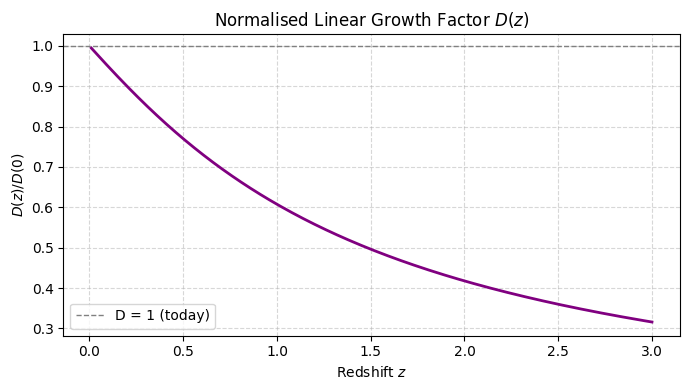

  D(z=0.3) = 0.8542
  D(z=0.5) = 0.7702
  D(z=1.0) = 0.6076
  D(z=2.0) = 0.4176


In [7]:
def growth_factor_D(z, H0, Om_m, Om_lambda):
    """Normalised linear growth factor D(z), with D(0) = 1."""
    g0    = growth_function_g(0.0, H0, Om_m, Om_lambda)
    D0raw = g0  # (1+0) = 1
    if np.isscalar(z):
        gz = growth_function_g(z, H0, Om_m, Om_lambda)
        return (gz / (1.0 + z)) / D0raw
    gz = np.array([growth_function_g(zv, H0, Om_m, Om_lambda) for zv in z])
    return (gz / (1.0 + z)) / D0raw

# ── Immediate verification ─────────────────────────────────────────────────────
D_z0 = growth_factor_D(1e-5, H0, Om_m, Om_lambda)
print(f"D(z -> 0) = {D_z0:.6f}  (expected ~1.0)")
assert abs(D_z0 - 1.0) < 0.005, f"D(z=0) = {D_z0:.4f}, should be ~1.0"

z_test = np.linspace(0.01, 3.0, 300)
D_test = growth_factor_D(z_test, H0, Om_m, Om_lambda)

assert np.all(np.diff(D_test) < 0), "D(z) should decrease with increasing z"
print("D(z) is monotonically decreasing with z: OK")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_test, D_test, 'purple', lw=2)
ax.axhline(1.0, color='gray', ls='--', lw=1, label='D = 1 (today)')
ax.set(xlabel='Redshift $z$', ylabel='$D(z)/D(0)$',
       title='Normalised Linear Growth Factor $D(z)$')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

for zv in [0.3, 0.5, 1.0, 2.0]:
    print(f"  D(z={zv}) = {growth_factor_D(zv, H0, Om_m, Om_lambda):.4f}")


### 3.5 Galaxy Bias $b(z)$

Observed galaxy counts are a **biased tracer** of the underlying dark matter field. On large scales, this bias is well approximated as a multiplicative factor $b$ relating the galaxy overdensity $\delta_g$ to the matter overdensity $\delta_m$:

$$\delta_g(\mathbf{x}, z) = b(z)\,\delta_m(\mathbf{x}, z)$$

The prescription used here is:

$$b(z) = \frac{b_0}{D_*(z)}, \quad D_*(z) = \frac{D(z)}{D(0)}$$

This form ensures that the **combination** $b(z)\,D(z) = b_0 D(0)$ is approximately constant, reflecting the fact that galaxies that are more biased at high $z$ are observed in regions that will, on average, grow into the same level of clustering as low-bias galaxies today. The result is that $b(z)$ **grows with redshift** as the growth factor decreases.

*Reference: Karim et al. (2025), Eq. 4.7.*


b(z -> 0) = 2.0000  (expected ~ b0 = 2.0)
b(z) is monotonically increasing with z (as D decreases): OK


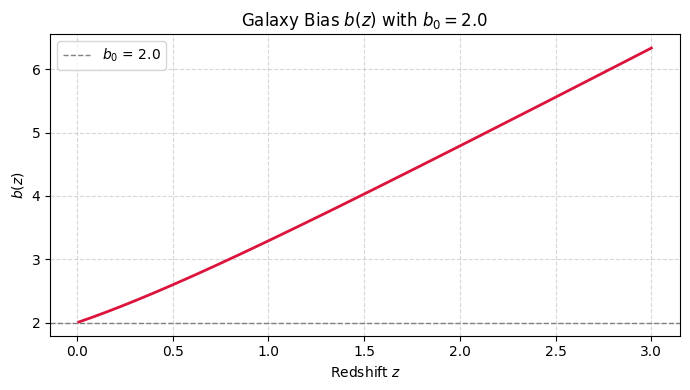

  b(z=0.0) = 2.0000
  b(z=0.3) = 2.3414
  b(z=1.0) = 3.2915
  b(z=1.5) = 4.0299


In [8]:
def bias_function(z, H0, Om_m, Om_lambda, b0=1.0):
    """Scale-dependent galaxy bias b(z) = b0 / D*(z). Karim et al. (2025) Eq. 4.7."""
    Dz = growth_factor_D(z, H0, Om_m, Om_lambda)
    D0 = growth_factor_D(0, H0, Om_m, Om_lambda)
    return b0 / (Dz / D0 + 1e-30)

# ── Immediate verification ─────────────────────────────────────────────────────
b_z0 = bias_function(1e-5, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
print(f"b(z -> 0) = {b_z0:.4f}  (expected ~ b0 = {Config.BIAS_B0})")
assert abs(b_z0 - Config.BIAS_B0) < 0.01

z_test = np.linspace(0.01, 3.0, 300)
b_test = bias_function(z_test, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)

assert np.all(np.diff(b_test) >= 0), "b(z) should increase with z (D decreases)"
print("b(z) is monotonically increasing with z (as D decreases): OK")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_test, b_test, 'crimson', lw=2)
ax.axhline(Config.BIAS_B0, color='gray', ls='--', lw=1, label=f'$b_0$ = {Config.BIAS_B0}')
ax.set(xlabel='Redshift $z$', ylabel='$b(z)$',
       title=f'Galaxy Bias $b(z)$ with $b_0 = {Config.BIAS_B0}$')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

for zv in [0.0, 0.3, 1.0, 1.5]:
    print(f"  b(z={zv}) = {bias_function(zv, H0, Om_m, Om_lambda, b0=Config.BIAS_B0):.4f}")


### 3.6 CMB Lensing Kernel $W^\kappa(z)$

CMB photons are gravitationally deflected by all the matter between us and the last-scattering surface at $z_* \approx 1100$. The lensing convergence $\kappa$ is a weighted projection of the matter density:

$$W^\kappa(z) = \frac{3\Omega_m H_0^2}{2c\,H(z)}\,(1+z)\,\chi(z)\,\frac{\chi_* - \chi(z)}{\chi_*}$$

The geometric factor $\chi(\chi_* - \chi)/\chi_*$ is the **lensing efficiency**: it is zero at both $z=0$ (no path behind us) and $z \to z_*$ (no path ahead), and peaks at the midpoint of the line of sight $z \sim 1{-}2$.

The explicit $1/H(z)$ factor arises because the Limber integral is written in terms of $dz$ rather than $d\chi$; the conversion is $d\chi = (c/H)\,dz$.

*References: Bianchini et al. (2015), Eqs. (3)–(4); Karim et al. (2025), Eq. 4.2.*


W_kappa >= 0 everywhere: OK
W_kappa peaks at z ~ 1.50  (max = 3.4100e-01)


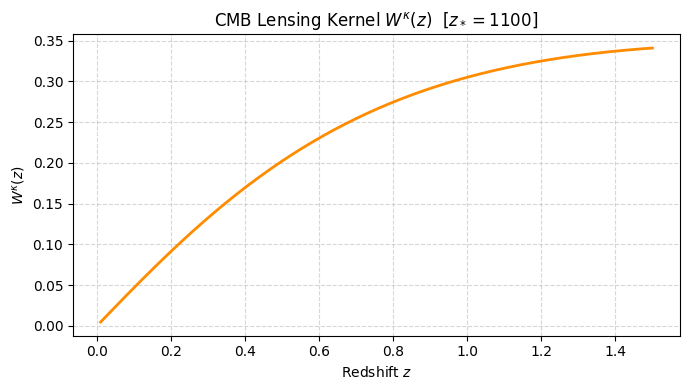

In [9]:
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    """
    CMB lensing weight W^kappa(z), including 1/H(z) for the dz-basis Limber integral.
    Bianchini et al. (2015) Eqs. (3)-(4).
    """
    Hz       = hubble_function(z, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0**2) / (2 * Config.c * Hz)
    chi_z    = comoving_distance_proper(z,      H0, Om_m, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
    return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star

# ── Immediate verification ─────────────────────────────────────────────────────
z_star = 1100.0
z_test = np.linspace(Config.Z_MIN, Config.Z_MAX, 300)
Wk_test = cmb_lensing_kernel(z_test, z_star, H0, Om_m, Om_lambda)

assert np.all(Wk_test >= 0), "W_kappa must be non-negative"
print(f"W_kappa >= 0 everywhere: OK")
z_peak = z_test[np.argmax(Wk_test)]
print(f"W_kappa peaks at z ~ {z_peak:.2f}  (max = {Wk_test.max():.4e})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_test, Wk_test, 'darkorange', lw=2)
ax.set(xlabel='Redshift $z$', ylabel=r'$W^\kappa(z)$',
       title='CMB Lensing Kernel $W^\kappa(z)$  [$z_* = 1100$]')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 3.7 Galaxy Redshift Distribution $n(z)$ and Full LOS Kernel $W^g(z)$

#### Galaxy Redshift Distribution

The survey redshift distribution is modelled as:

$$n(z) \propto z^2\,e^{-z/z_0}, \quad z_0 = 0.3$$

This is a standard parametrisation for a photometric galaxy survey (sometimes written as a modified Smail distribution). The $z^2$ rise reflects the increasing comoving volume at low $z$, while the exponential suppresses the tail at high $z$ where the survey becomes incomplete. It is normalised so $\int n(z)\,dz = 1$.

#### Full Galaxy LOS Kernel

The galaxy kernel has two contributions (Bianchini et al. 2015, Eq. 6):

$$W^g(z) = \underbrace{b(z)\,n(z)}_{\text{clustering}} + \underbrace{\mu(z)}_{\text{magnification}}$$

**Clustering term** $b(z)\,n(z)$: galaxies trace matter with bias $b(z)$, weighted by their redshift distribution $n(z)$.

**Magnification term** $\mu(z)$: gravitational lensing by foreground structure changes both the apparent flux and the solid angle of background sources, altering the observed number counts. For a flux-limited survey with logarithmic slope $\alpha$ of the luminosity function:

$$\mu(z) = \frac{3\Omega_m H_0^2}{2c\,H(z)}\,(1+z)\,\chi(z) \int_z^\infty \left(1 - \frac{\chi(z)}{\chi(z')}\right)(\alpha-1)\,n(z')\,dz'$$

With $\alpha = 2.225$ (Karim et al. 2025), the magnification contribution is positive and adds power at all scales. The decomposition plot below shows how large this contribution is relative to the clustering term across redshift.

*References: Bianchini et al. (2015), Eq. (6); Karim et al. (2025), Eqs. (4.3)–(4.4).*


n(z) normalisation: int n(z) dz = 1.000000  (expected 1.0)


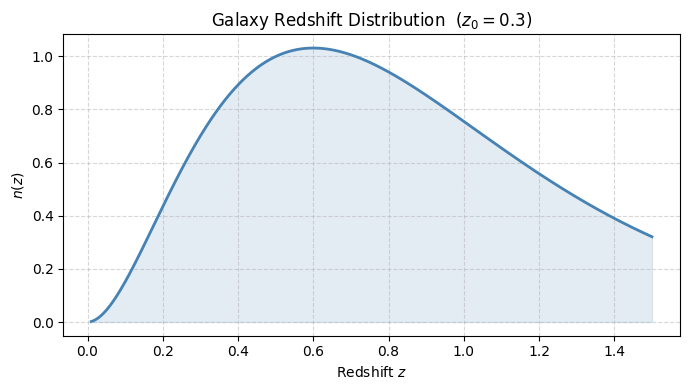

n(z) peaks at z ~ 0.60


In [10]:
# ── Galaxy n(z): build and normalise ──────────────────────────────────────────
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)
z0     = Config.Z0_GALAXY
_raw   = 2.0 * z0 * (z_grid / z0)**2 * np.exp(-z_grid / z0)
_norm  = simpson(_raw, z_grid)
dNdz   = _raw / _norm
dNdz_func = interp1d(z_grid, dNdz, kind='linear', bounds_error=False, fill_value=0.0)

norm_check = simpson(dNdz, z_grid)
print(f"n(z) normalisation: int n(z) dz = {norm_check:.6f}  (expected 1.0)")
assert abs(norm_check - 1.0) < 1e-4, "n(z) must integrate to 1"

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_grid, dNdz, 'steelblue', lw=2)
ax.fill_between(z_grid, dNdz, alpha=0.15, color='steelblue')
ax.set(xlabel='Redshift $z$', ylabel='$n(z)$',
       title=f'Galaxy Redshift Distribution  ($z_0 = {z0}$)')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
print(f"n(z) peaks at z ~ {z_grid[np.argmax(dNdz)]:.2f}")


W_g sample range: [9.7954e-03, 2.9277e+00]


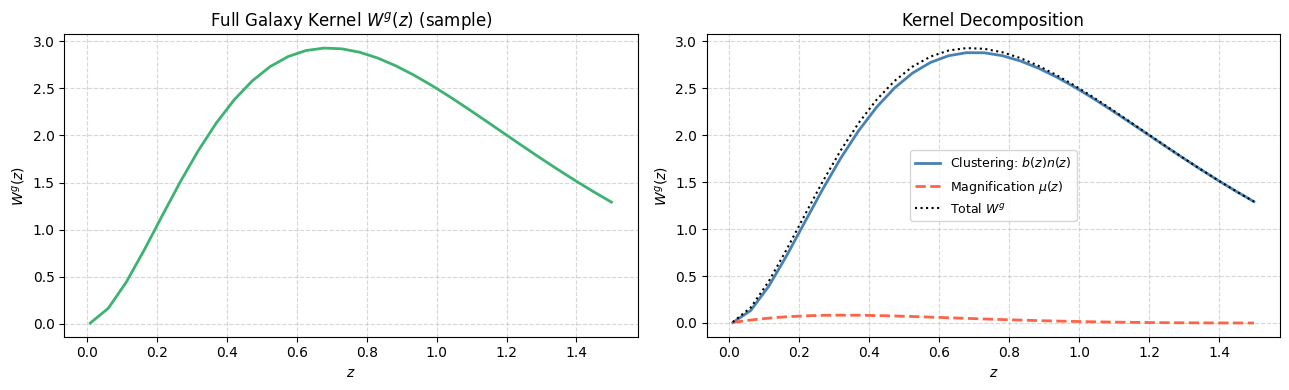

In [11]:
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    """
    Full galaxy LOS kernel W^g(z) = b(z)*n(z) + magnification term.
    Includes 1/H(z) for consistency with the dz-basis Limber integral.
    Bianchini et al. (2015) Eq. (6); Karim et al. (2025) Eqs. (4.3)-(4.4).
    """
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z     = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    Hz        = hubble_function(z, H0, Om_m, Om_lambda)

    def integrand(zp):
        chi_zp = comoving_distance_proper(zp, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_zp) * (Config.alpha - 1) * dN_dz_func(zp)

    integral, _ = quad(integrand, z, 10.0)
    mu_pref = (3 * Om_m * H0**2) / (2 * Config.c * Hz) * (1 + z) * chi_z
    return bias_term + mu_pref * integral

# ── Immediate verification and plot ───────────────────────────────────────────
bias_func_local = lambda z: bias_function(z, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)

# Sample on a coarser grid first for a quick sanity check
z_sample = np.linspace(Config.Z_MIN, Config.Z_MAX, 30)
Wg_sample = np.array([
    galaxy_lensing_kernel(z, z_grid, dNdz_func, bias_func_local, H0, Om_m, Om_lambda)
    for z in z_sample
])
print(f"W_g sample range: [{Wg_sample.min():.4e}, {Wg_sample.max():.4e}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(z_sample, Wg_sample, 'mediumseagreen', lw=2)
axes[0].set(xlabel='$z$', ylabel='$W^g(z)$', title='Full Galaxy Kernel $W^g(z)$ (sample)')
axes[0].grid(True, ls='--', alpha=0.5)

# Decompose bias vs magnification contributions for insight
Wg_bias = np.array([bias_func_local(z) * dNdz_func(z) for z in z_sample])
Wg_mag  = Wg_sample - Wg_bias
axes[1].plot(z_sample, Wg_bias, 'steelblue', lw=2, label='Clustering: $b(z)n(z)$')
axes[1].plot(z_sample, Wg_mag,  'tomato',    lw=2, ls='--', label='Magnification $\mu(z)$')
axes[1].plot(z_sample, Wg_sample, 'k', lw=1.5, ls=':', label='Total $W^g$')
axes[1].set(xlabel='$z$', ylabel='$W^g(z)$', title='Kernel Decomposition')
axes[1].legend(fontsize=9); axes[1].grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


## 4. Power Spectrum Utilities

The matter power spectrum $P(k, z)$ is the key ingredient in the Limber integral. Computing it from first principles (e.g. Boltzmann codes) is expensive; instead we use two pre-trained neural-network emulators.

### Emulator Overview

**BACCO** ([Angulo et al. 2021](https://arxiv.org/abs/2004.06245)) emulates the *nonlinear* matter power spectrum $P^{GR}(k, z)$ for general relativity over a wide range of cosmological parameters. It takes cosmological parameters and a scale factor $a = 1/(1+z)$ and returns $P(k)$ on a pre-defined $k$ grid. The parameter `omega_cold` = $\Omega_m - \Omega_b$ separates cold dark matter from baryons, as BACCO was trained on the total cold matter spectrum.

**EMANTIS** ([Sáez-Casares et al. 2024](https://arxiv.org/abs/2309.03944)) emulates the *boost factor* $B(k, z) = P^{f(R)}(k,z) / P^{GR}(k,z)$, trained on f(R) Hu-Sawicki gravity simulations. The full f(R) power spectrum is then:

$$P^{f(R)}(k, z) = B(k, z) \times P^{GR}(k, z)$$

### Log-Log Interpolation Strategy

The emulators return $P(k)$ on a fixed $k$ grid, but the Limber integral requires $P$ at $k = (\ell+\tfrac{1}{2})/\chi(z)$ for arbitrary $\ell$ and $z$. We bridge this gap with a **cubic spline in log-log space**:

$$\ln P(k) \approx \text{cubic spline of } \{\ln k_i,\, \ln P(k_i)\}$$

Log-log interpolation is preferred because $P(k)$ spans many decades in both $k$ and amplitude and behaves as a power law in each regime — the interpolation is smooth and accurate with far fewer nodes than in linear space.

A **separate interpolator is built for each redshift slice** in `z_grid`, so the integrand at any $(\ell, z)$ pair can be evaluated by simply looking up the corresponding interpolator and querying it at the appropriate $k$.


### 4.1 BACCO Emulator — Initialise

In [12]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """Initialise BACCO nonlinear matter power-spectrum emulator and return (emulator, k)."""
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k

# ── Initialise and report ──────────────────────────────────────────────────────
print("Initialising BACCO emulator (this may take ~30 s) …")
bacco_emu, k = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
print(f"  k grid : {k.min():.5f} – {k.max():.3f} h/Mpc  ({len(k)} points)")
assert len(k) == Config.BACCO_N_K
assert np.all(np.diff(k) > 0), "k grid must be monotonically increasing"
print("  k grid is log-spaced and monotonically increasing: OK")


Initialising BACCO emulator (this may take ~30 s) …


100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:01 Time:  0:00:01
100% (2304000 of 2304000) |##############| Elapsed Time: 0:00:01 Time:  0:00:01
100% (2785280 of 2785280) |##############| Elapsed Time: 0:00:01 Time:  0:00:01
100% (2293760 of 2293760) |##############| Elapsed Time: 0:00:01 Time:  0:00:01


  k grid : 0.01000 – 4.903 h/Mpc  (200 points)
  k grid is log-spaced and monotonically increasing: OK


### 4.2 Nonlinear $P(k, z)$ from BACCO

`get_bacco_nonlinear_pk` translates our `Config.COSMO_PARAMS` dictionary into BACCO's own parameter naming convention and queries the emulator at a given scale factor `aexp` = $1/(1+z)$. Two behaviours are worth noting:

- **`omega_cold`** = $\Omega_m - \Omega_b$: BACCO's convention separates the cold dark matter contribution from baryons.
- **`cold=False`**: returns the total matter power spectrum (CDM + baryons), which is what the Limber integral requires.

The verification below checks that $P(k, z=0) \geq P(k, z=1)$ at every $k$ — matter clustering grows over time, so the present-day spectrum always has more power than the past.


P(k) at z=0: range [4.127e+01, 3.747e+04] (Mpc/h)^3
P(k) at z=1: range [9.605e+00, 1.466e+04] (Mpc/h)^3
P(k, z=0) >= P(k, z=1) for all k: OK (structure grows toward z=0)


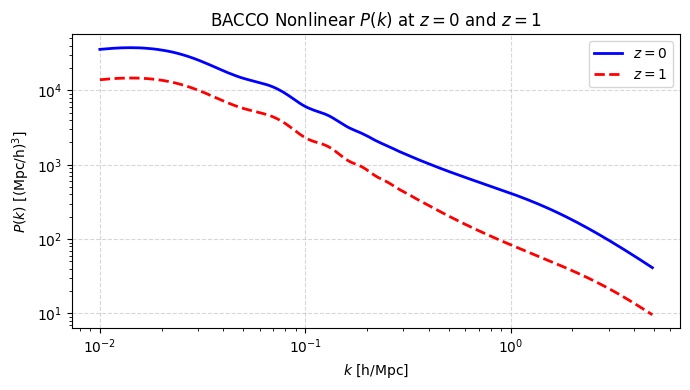

In [13]:
def get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0):
    """Return nonlinear P(k) [(Mpc/h)^3] at scale factor aexp from BACCO."""
    params_bacco = {
        "omega_cold":    params["Omega_m"] - params["Omega_b"],
        "sigma8_cold":   params["sigma8"],
        "omega_baryon":  params["Omega_b"],
        "ns":            params["n_s"],
        "hubble":        params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0":            params.get("w0", -1.0),
        "wa":            params.get("wa", 0.0),
        "expfactor":     aexp
    }
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    return pk_nl

# ── Evaluate at z=0 and z=1, then plot ────────────────────────────────────────
pk_z0 = get_bacco_nonlinear_pk(bacco_emu, Config.COSMO_PARAMS, k, aexp=1.0)
pk_z1 = get_bacco_nonlinear_pk(bacco_emu, Config.COSMO_PARAMS, k, aexp=0.5)

assert np.all(pk_z0 > 0), "P(k) must be positive"
print(f"P(k) at z=0: range [{pk_z0.min():.3e}, {pk_z0.max():.3e}] (Mpc/h)^3")
print(f"P(k) at z=1: range [{pk_z1.min():.3e}, {pk_z1.max():.3e}] (Mpc/h)^3")
assert np.all(pk_z0 >= pk_z1), "P(k,z=0) should dominate P(k,z=1) at all k"
print("P(k, z=0) >= P(k, z=1) for all k: OK (structure grows toward z=0)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(k, pk_z0, 'b-',  lw=2, label='$z=0$')
ax.loglog(k, pk_z1, 'r--', lw=2, label='$z=1$')
ax.set(xlabel='$k$ [h/Mpc]', ylabel='$P(k)$ [(Mpc/h)$^3$]',
       title='BACCO Nonlinear $P(k)$ at $z=0$ and $z=1$')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 4.3 EMANTIS — f(R) Boost Factor $B(k, z)$

**f(R) gravity** is a class of modified gravity theories in which the Einstein–Hilbert action is extended by replacing the Ricci scalar $R$ with a general function $f(R)$. The Hu–Sawicki model parametrises the deviation from GR by a single number $f_{R0}$, the background value of $df/dR$ today:

$$f_{R0} = \left.\frac{df}{dR}\right|_{z=0}$$

A larger $|f_{R0}|$ means a stronger deviation from GR. The sign convention used here is $\log_{10}|f_{R0}|$, so `-4` is the strongest modification tested ($|f_{R0}| = 10^{-4}$) and `-6` is the weakest ($|f_{R0}| = 10^{-6}$).

Physically, f(R) gravity enhances structure growth on small to intermediate scales through an additional "fifth force" mediated by the scalar degree of freedom (the scalaron). This produces a **scale-dependent boost** $B(k, z) \geq 1$ that rises steeply at $k \gtrsim 0.1\,h/\text{Mpc}$ and is larger for models with greater $|f_{R0}|$.

EMANTIS predicts this boost directly, avoiding the need to run separate f(R) N-body simulations.


Initialising EMANTIS emulator …
  EMANTIS ready.
  Boost log|fR0|=-4: range [1.0000, 1.4159]
  Boost log|fR0|=-5: range [1.0000, 1.2331]
  Boost log|fR0|=-6: range [1.0000, 1.0470]


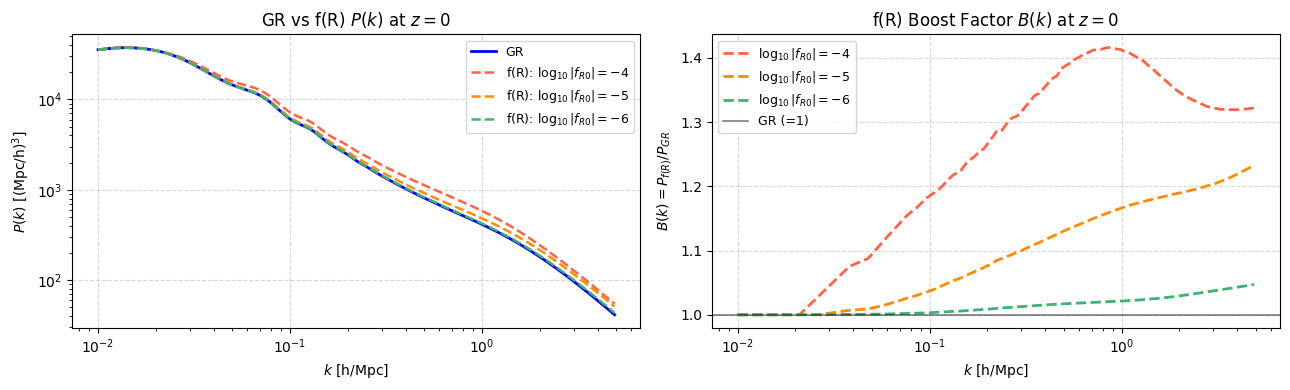

All f(R) boosts >= 1: OK (f(R) enhances power)


In [14]:
def initialize_emantis_emulator(verbose=False):
    """Initialise EMANTIS f(R) gravity boost emulator."""
    return NonLinearMGBoostEmulator(verbose=verbose)

def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """Return B(k) = P_fR(k) / P_GR(k) for a given log10|fR0| value."""
    params_emantis = {
        "Omega_m":     params["Omega_m"],
        "Omega_b":     params["Omega_b"],
        "h":           params["h"],
        "n_s":         params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0":      logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)

# ── Initialise EMANTIS ─────────────────────────────────────────────────────────
print("Initialising EMANTIS emulator …")
emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)
print("  EMANTIS ready.")

# ── Compute boost at z=0 for all fR values, then plot ──────────────────────────
colors = ['tomato', 'darkorange', 'mediumseagreen']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(k, pk_z0, 'b-', lw=2, label='GR')
for fv, col in zip(Config.FR_VALUES, colors):
    boost = compute_fR_boost(emantis_emu, Config.COSMO_PARAMS, fv, k, aexp=1.0)
    assert np.all(boost >= 1.0 - 1e-3), f"Boost for log|fR0|=-{fv} should be >= 1"
    axes[0].loglog(k, pk_z0 * boost, '--', lw=1.8, color=col,
                   label=rf'f(R): $\log_{{10}}|f_{{R0}}|=-{fv}$')
axes[0].set(xlabel='$k$ [h/Mpc]', ylabel='$P(k)$ [(Mpc/h)$^3$]',
            title='GR vs f(R) $P(k)$ at $z=0$')
axes[0].legend(fontsize=9); axes[0].grid(True, ls='--', alpha=0.5)

for fv, col in zip(Config.FR_VALUES, colors):
    boost = compute_fR_boost(emantis_emu, Config.COSMO_PARAMS, fv, k, aexp=1.0)
    axes[1].semilogx(k, boost, '--', lw=2, color=col,
                     label=rf'$\log_{{10}}|f_{{R0}}|=-{fv}$')
    print(f"  Boost log|fR0|=-{fv}: range [{boost.min():.4f}, {boost.max():.4f}]")
axes[1].axhline(1.0, color='k', lw=1.2, ls='-', alpha=0.5, label='GR (=1)')
axes[1].set(xlabel='$k$ [h/Mpc]', ylabel='$B(k) = P_{f(R)}/P_{GR}$',
            title='f(R) Boost Factor $B(k)$ at $z=0$')
axes[1].legend(fontsize=9); axes[1].grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
print("All f(R) boosts >= 1: OK (f(R) enhances power)")


### 4.4 Log–Log $P(k)$ Interpolator

`create_power_spectrum_interpolator` wraps `scipy.interpolate.interp1d` in log-log space. Setting `fill_value='extrapolate'` allows mild extrapolation beyond the emulator $k$ range, but the `check_k_bounds` clipping in `build_pk_interpolators_over_z` ensures we never stray far from the training domain.

The round-trip test below confirms that the interpolator reproduces the original emulator values at interior $k$ points to better than 0.1% — well within the emulator's own accuracy budget.


Interpolator round-trip max relative error: 1.96e-15
Round-trip error < 0.1%: OK


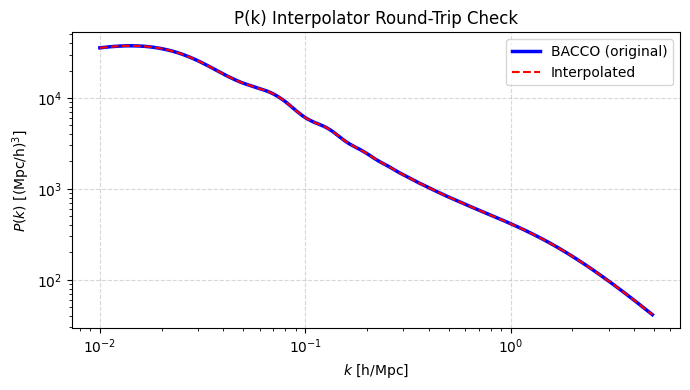

In [15]:
def create_power_spectrum_interpolator(k, pk):
    """
    Build a log-log cubic spline interpolator for P(k).
    Stable across power-law regimes; evaluates as exp(interp(log(k))).
    """
    return interp1d(
        np.log(k), np.log(pk + 1e-50),
        kind='cubic', bounds_error=False, fill_value='extrapolate'
    )

# ── Round-trip test ────────────────────────────────────────────────────────────
interp_test = create_power_spectrum_interpolator(k, pk_z0)
k_test_pts  = k[5:-5:10]   # interior points only (avoid edge extrapolation)
P_orig      = pk_z0[5:-5:10]
P_interp    = np.exp(interp_test(np.log(k_test_pts)))
rel_errors  = np.abs(P_interp - P_orig) / P_orig
print(f"Interpolator round-trip max relative error: {rel_errors.max():.2e}")
assert rel_errors.max() < 1e-3, "Interpolator round-trip error too large"
print("Round-trip error < 0.1%: OK")

# ── Visual round-trip ──────────────────────────────────────────────────────────
k_fine = np.logspace(np.log10(k.min()), np.log10(k.max()), 500)
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(k,      pk_z0,                               'b-',  lw=2.5, label='BACCO (original)')
ax.loglog(k_fine, np.exp(interp_test(np.log(k_fine))), 'r--', lw=1.5, label='Interpolated')
ax.set(xlabel='$k$ [h/Mpc]', ylabel='$P(k)$ [(Mpc/h)$^3$]',
       title='P(k) Interpolator Round-Trip Check')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 4.5 Building the Full $P(k, z)$ Grids

`build_pk_interpolators_over_z` and `build_pk_interpolators_over_z_fr` loop over every redshift slice in `z_grid` and call the emulators to produce one interpolator per slice. This pre-computation takes most of the wall-clock time in the notebook but is done only once per gravity model.

The resulting objects, `pk_interp_gr_z` and `fr_pk_interps[fv]`, are Python lists indexed by redshift, each element being a log-log spline over $k$. During the Limber integral in Section 6, evaluating the power spectrum at any $(\ell, z_j)$ pair is a single call to `pk_interp_list[j](log(k))`.

The spot-check table below verifies that $P^{f(R)}(k, z) / P^{GR}(k, z) \geq 1$ at representative $(k, z)$ combinations — a necessary physical consistency check.


Safe k bounds: [0.01100, 4.4129] h/Mpc
Building GR P(k,z) grid for 500 redshift slices …
  GR grid ready (500 interpolators)
Building f(R) P(k,z) grid for log10|fR0| = -4 …
  f(R)-4 grid ready (500 interpolators)
Building f(R) P(k,z) grid for log10|fR0| = -5 …
  f(R)-5 grid ready (500 interpolators)
Building f(R) P(k,z) grid for log10|fR0| = -6 …
  f(R)-6 grid ready (500 interpolators)

Spot-check P_fR / P_GR at k_mid:
  z=0.01: P_GR=2.030e+03  |  ratio_fR4=1.2851  ratio_fR5=1.0842  ratio_fR6=1.0099
  z=0.31: P_GR=1.430e+03  |  ratio_fR4=1.2298  ratio_fR5=1.0635  ratio_fR6=1.0082
  z=0.76: P_GR=8.706e+02  |  ratio_fR4=1.1576  ratio_fR5=1.0377  ratio_fR6=1.0046
  z=1.20: P_GR=5.643e+02  |  ratio_fR4=1.1017  ratio_fR5=1.0206  ratio_fR6=1.0024
  z=1.50: P_GR=4.394e+02  |  ratio_fR4=1.0734  ratio_fR5=1.0133  ratio_fR6=1.0016


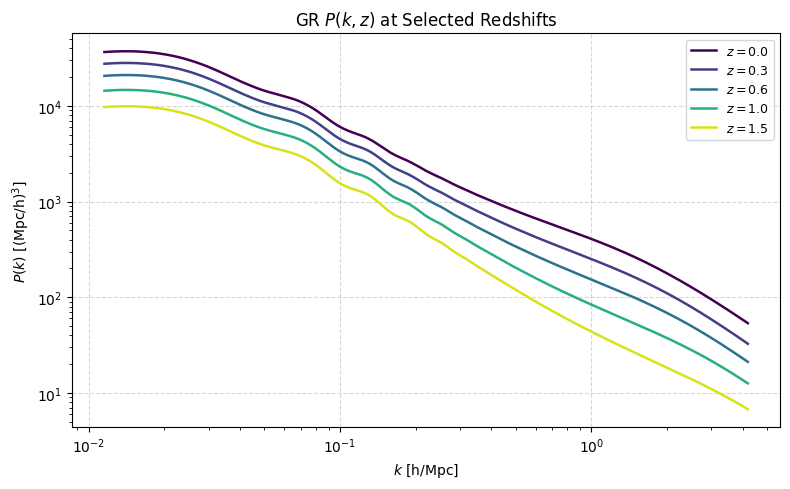

In [16]:
def build_pk_interpolators_over_z(emulator, params, k, z_grid):
    """Return a list of log-log P(k) interpolators, one per z in z_grid (GR)."""
    return [
        create_power_spectrum_interpolator(
            k, get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0/(1.0+z))
        )
        for z in z_grid
    ]

def build_pk_interpolators_over_z_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    """Return a list of log-log P(k) interpolators, one per z in z_grid (f(R))."""
    interps = []
    for z in z_grid:
        aexp  = 1.0 / (1.0 + z)
        pk_gr = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        boost = compute_fR_boost(emantis_emu, params, logfR0, k, aexp=aexp)
        interps.append(create_power_spectrum_interpolator(k, pk_gr * boost))
    return interps

def check_k_bounds(k_vals, k_min, k_max, ell, label, threshold=0.05):
    """Clip k values to safe emulator bounds to avoid extrapolation artefacts."""
    return np.clip(k_vals, k_min, k_max)

# ── Build all grids ────────────────────────────────────────────────────────────
k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY
print(f"Safe k bounds: [{k_min_safe:.5f}, {k_max_safe:.4f}] h/Mpc")

print(f"Building GR P(k,z) grid for {Config.N_Z} redshift slices …")
pk_interp_gr_z = build_pk_interpolators_over_z(bacco_emu, Config.COSMO_PARAMS, k, z_grid)
print(f"  GR grid ready ({len(pk_interp_gr_z)} interpolators)")

fr_pk_interps = {}
for fv in Config.FR_VALUES:
    print(f"Building f(R) P(k,z) grid for log10|fR0| = -{fv} …")
    fr_pk_interps[fv] = build_pk_interpolators_over_z_fr(
        bacco_emu, emantis_emu, Config.COSMO_PARAMS, fv, k, z_grid
    )
    print(f"  f(R)-{fv} grid ready ({len(fr_pk_interps[fv])} interpolators)")

# ── Spot-check: P_fR >= P_GR at all z ─────────────────────────────────────────
k_check = k[len(k)//2]  # mid-range k
z_checks = [0, 100, 250, 400, 499]
print("\nSpot-check P_fR / P_GR at k_mid:")
for zi in z_checks:
    P_gr = np.exp(pk_interp_gr_z[zi](np.log(k_check)))
    for fv in Config.FR_VALUES:
        P_fr = np.exp(fr_pk_interps[fv][zi](np.log(k_check)))
        ratio = P_fr / P_gr
        assert ratio >= 1.0 - 1e-3, f"f(R) should not reduce power at z={z_grid[zi]:.2f}"
    print(f"  z={z_grid[zi]:.2f}: P_GR={P_gr:.3e}  |  " +
          "  ".join(f"ratio_fR{fv}={np.exp(fr_pk_interps[fv][zi](np.log(k_check)))/P_gr:.4f}"
                    for fv in Config.FR_VALUES))

# ── P(k) at several redshifts ─────────────────────────────────────────────────
z_show   = [0.0, 0.3, 0.6, 1.0, 1.5]
k_plot   = np.logspace(np.log10(k_min_safe*1.05), np.log10(k_max_safe*0.95), 300)
z_idx    = [np.argmin(np.abs(z_grid - zv)) for zv in z_show]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for idx, zv in zip(z_idx, z_show):
    ax.loglog(k_plot, np.exp(pk_interp_gr_z[idx](np.log(k_plot))),
              color=cmap(zv / 1.6), lw=1.8, label=f'$z={zv}$')
ax.set(xlabel='$k$ [h/Mpc]', ylabel='$P(k)$ [(Mpc/h)$^3$]',
       title='GR $P(k,z)$ at Selected Redshifts')
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


## 5. Pre-compute Redshift Grid Quantities

Before evaluating the Limber integrals, we pre-compute all redshift-dependent arrays on the shared `z_grid`. Pre-computing avoids redundant calls to `quad` and ensures every quantity is evaluated at the same redshift nodes as the numerical quadrature.

The arrays built here are:

| Array | Symbol | Used in |
|---|---|---|
| `chi_vals` | $\chi(z_i)$ | Limber $k = (\ell+\tfrac{1}{2})/\chi$ mapping; kernel prefactors |
| `H_vals` | $H(z_i)$ | Limber prefactor $H(z)/c$; kernel prefactors |
| `D_vals`, `D0` | $D(z_i)$, $D(0)$ | Bias function $b(z) = b_0/D_*(z)$ |
| `Wkappa_vals` | $W^\kappa(z_i)$ | Cross-spectrum integrand |
| `Wg_vals` | $W^g(z_i)$ | Auto- and cross-spectrum integrand |

The three-panel plot confirms that $\chi(z)$ and $H(z)$ are well-behaved and that the growth factor decreases monotonically — all expected physically.


Redshift grid quantities:
  chi : [44.6, 4508.9] Mpc
  H   : [67.3, 158.6] km/s/Mpc
  D   : [0.4963, 0.9949]  (D0 = 1.0000)
chi monotone increasing, D monotone decreasing: OK


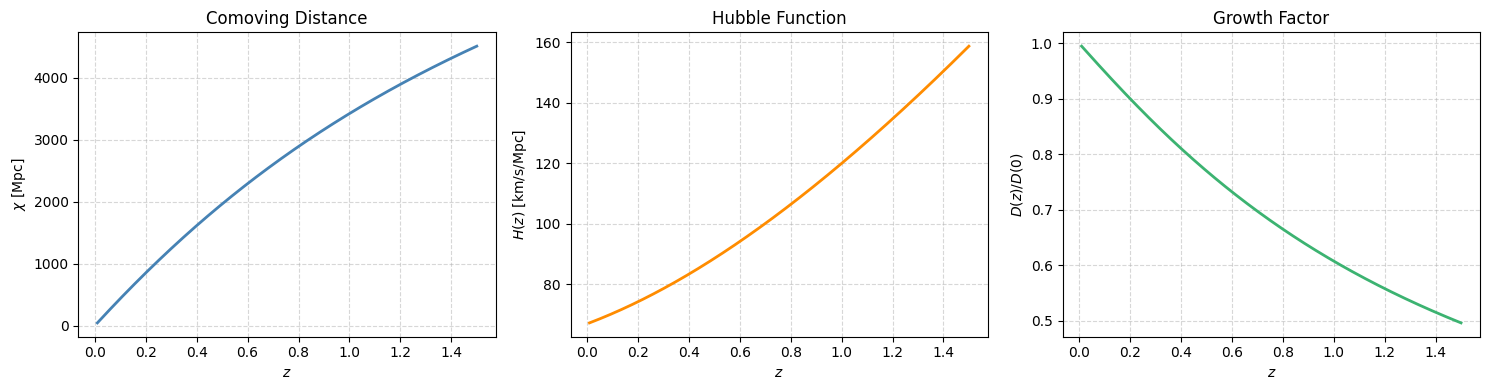

In [17]:
# ── chi, H, D on the full grid ─────────────────────────────────────────────────
chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)
H_vals   = hubble_function(z_grid, H0, Om_m, Om_lambda)
D_vals   = growth_factor_D(z_grid, H0, Om_m, Om_lambda)
D0       = growth_factor_D(0.0, H0, Om_m, Om_lambda)

print("Redshift grid quantities:")
print(f"  chi : [{chi_vals.min():.1f}, {chi_vals.max():.1f}] Mpc")
print(f"  H   : [{H_vals.min():.1f}, {H_vals.max():.1f}] km/s/Mpc")
print(f"  D   : [{D_vals.min():.4f}, {D_vals.max():.4f}]  (D0 = {D0:.4f})")

assert np.all(np.diff(chi_vals) > 0), "chi(z) not monotone"
assert np.all(np.diff(D_vals)   < 0), "D(z) not decreasing"
print("chi monotone increasing, D monotone decreasing: OK")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(z_grid, chi_vals, lw=2, color='steelblue')
axes[0].set(xlabel='$z$', ylabel=r'$\chi$ [Mpc]', title='Comoving Distance'); axes[0].grid(True, ls='--', alpha=0.5)
axes[1].plot(z_grid, H_vals, lw=2, color='darkorange')
axes[1].set(xlabel='$z$', ylabel='$H(z)$ [km/s/Mpc]', title='Hubble Function'); axes[1].grid(True, ls='--', alpha=0.5)
axes[2].plot(z_grid, D_vals, lw=2, color='mediumseagreen')
axes[2].set(xlabel='$z$', ylabel='$D(z)/D(0)$', title='Growth Factor'); axes[2].grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### CMB Lensing and Galaxy Kernels on the Full Grid

The CMB lensing kernel $W^\kappa(z)$ is fast to evaluate (no quadrature needed, just a closed-form expression). The galaxy kernel $W^g(z)$ requires a numerical integral over the galaxy distribution for each $z$ (the magnification term), making it the most expensive pre-computation step.

The three-panel plot shows all three normalised weight functions together. Their relative widths and peak positions determine which redshift range contributes most to each angular power spectrum:

- $n(z)$ and $W^g(z)$ peak near $z \sim 0.6{-}0.8$ for this survey model.
- $W^\kappa(z)$ is broad, peaking near $z \sim 1{-}2$, because CMB photons are lensed by matter distributed across a much wider redshift range.

The overlap between $W^g$ and $W^\kappa$ controls the amplitude of $C_\ell^{\kappa g}$: a larger overlap means a stronger cross-correlation.


W_kappa peak at z ~ 1.50, value = 3.4100e-01
Computing full W_g(z) on 500 points (includes magnification integral) …
W_g range: [9.7954e-03, 2.9288e+00]


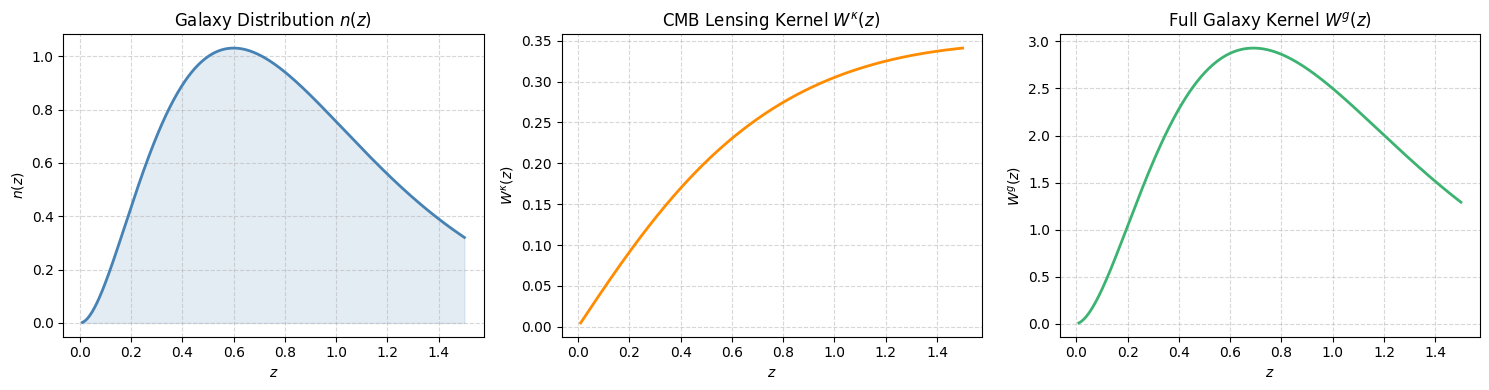

In [18]:
# ── CMB lensing kernel on full grid ───────────────────────────────────────────
z_star      = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)

assert np.all(Wkappa_vals >= 0), "W_kappa must be non-negative"
print(f"W_kappa peak at z ~ {z_grid[np.argmax(Wkappa_vals)]:.2f}, "
      f"value = {Wkappa_vals.max():.4e}")

# ── Full galaxy kernel on full grid ───────────────────────────────────────────
print(f"Computing full W_g(z) on {Config.N_Z} points (includes magnification integral) …")
bias_func_local = lambda z: bias_function(z, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
Wg_vals = np.array([
    galaxy_lensing_kernel(z, z_grid, dNdz_func, bias_func_local, H0, Om_m, Om_lambda)
    for z in z_grid
])
print(f"W_g range: [{Wg_vals.min():.4e}, {Wg_vals.max():.4e}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(z_grid, dNdz, 'steelblue', lw=2)
axes[0].fill_between(z_grid, dNdz, alpha=0.15, color='steelblue')
axes[0].set(xlabel='$z$', ylabel='$n(z)$', title='Galaxy Distribution $n(z)$')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(z_grid, Wkappa_vals, 'darkorange', lw=2)
axes[1].set(xlabel='$z$', ylabel=r'$W^{\kappa}(z)$', title='CMB Lensing Kernel $W^\kappa(z)$')
axes[1].grid(True, ls='--', alpha=0.5)

axes[2].plot(z_grid, Wg_vals, 'mediumseagreen', lw=2)
axes[2].set(xlabel='$z$', ylabel='$W^g(z)$', title='Full Galaxy Kernel $W^g(z)$')
axes[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()


## 6. Limber Angular Power Spectra

### The Limber Approximation

For a projected observable $A$ with a smooth line-of-sight kernel $W^A(z)$, the full angular power spectrum involves spherical Bessel functions and is expensive to compute. The **Limber approximation** (LoVerde & Afshordi 2008) replaces this with a much simpler 1D integral:

$$C_\ell^{AB} = \int dz\, \frac{H(z)}{c\,\chi^2(z)}\, W^A(z)\, W^B(z)\, P\!\left(k = \frac{\ell + \tfrac{1}{2}}{\chi(z)},\, z\right)$$

The approximation is accurate to ~1% for $\ell \gtrsim 10$ when the kernels $W^A$ and $W^B$ are broad in $z$ — which is the case here for both $W^g$ and $W^\kappa$.

The two spectra computed are:

| Spectrum | $W^A$ | $W^B$ | Bianchini eq. |
|---|---|---|---|
| $C_\ell^{gg}$ | $W^g$ | $W^g$ | Eq. (8) |
| $C_\ell^{\kappa g}$ | $W^\kappa$ | $W^g$ | Eq. (7) |

### Implementation Notes

- The Limber $k$ mapping uses $k = (\ell + \tfrac{1}{2})/\chi(z)$ (LoVerde & Afshordi 2008) rather than the cruder $k = \ell/\chi$.
- For each $\ell$ and each redshift node $z_j$, the power spectrum is retrieved by calling the pre-built interpolator `pk_interp_list[j](log(k))`.
- The $z$ integral is evaluated with `scipy.integrate.simpson` (composite Simpson's rule), which is $O(h^4)$ accurate on a uniform grid.
- $k$ values that fall outside the emulator's training range are clipped to `[k_min_safe, k_max_safe]` by `check_k_bounds`.

The integrand plots below (at $\ell = 100$) reveal which redshifts contribute most to each spectrum.


C_ell^{gg} spot-check at ell=100: 3.6289e-06


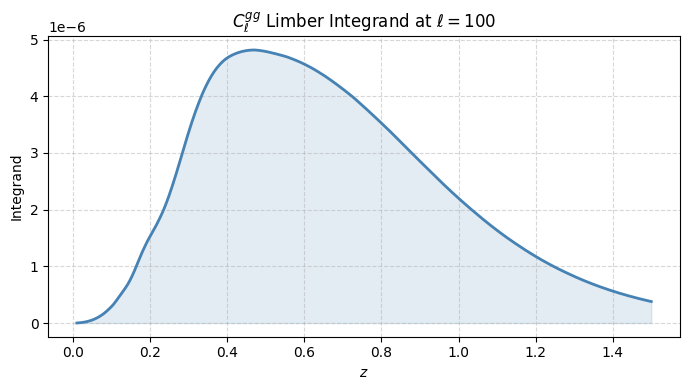

In [19]:
def compute_Cl_galaxy_auto(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0, k_min=None, k_max=None
):
    """
    Galaxy auto-spectrum C_ell^{gg} via Limber approximation.
    Bianchini et al. (2015) Eq. (8).
    """
    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "Cgg") if k_min else k_vals
        try:
            P_kz = np.exp([pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))])
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wg_vals ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl

# ── Immediate spot-check: plot integrand at ell=100 ───────────────────────────
ell_spot = 100.0
k_spot   = (ell_spot + 0.5) / chi_vals
k_clip   = np.clip(k_spot, k_min_safe, k_max_safe)
P_spot   = np.exp([pk_interp_gr_z[j](np.log(k_clip[j])) for j in range(len(z_grid))])
intgd_gg = (H_vals / Config.c) * (Wg_vals ** 2) * P_spot / (chi_vals ** 2)
Cl_gg_spot = simpson(intgd_gg, z_grid)
print(f"C_ell^{{gg}} spot-check at ell=100: {Cl_gg_spot:.4e}")
assert Cl_gg_spot > 0, "C_ell^gg must be positive"

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_grid, intgd_gg, 'steelblue', lw=2)
ax.set(xlabel='$z$', ylabel='Integrand',
       title=r'$C_\ell^{gg}$ Limber Integrand at $\ell=100$')
ax.fill_between(z_grid, intgd_gg, alpha=0.15, color='steelblue')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### Cross-Spectrum $C_\ell^{\kappa g}$

The cross-spectrum integrand is structurally identical to the auto-spectrum but replaces one factor of $W^g$ with $W^\kappa$. Because $W^\kappa$ peaks at higher redshift than $W^g$, the cross-spectrum integrand has a different shape — it is more spread out and shifted toward higher $z$ compared to the $C_\ell^{gg}$ integrand.

The side-by-side comparison below makes this difference immediately visible.


C_ell^{kg} spot-check at ell=100: 3.5315e-07


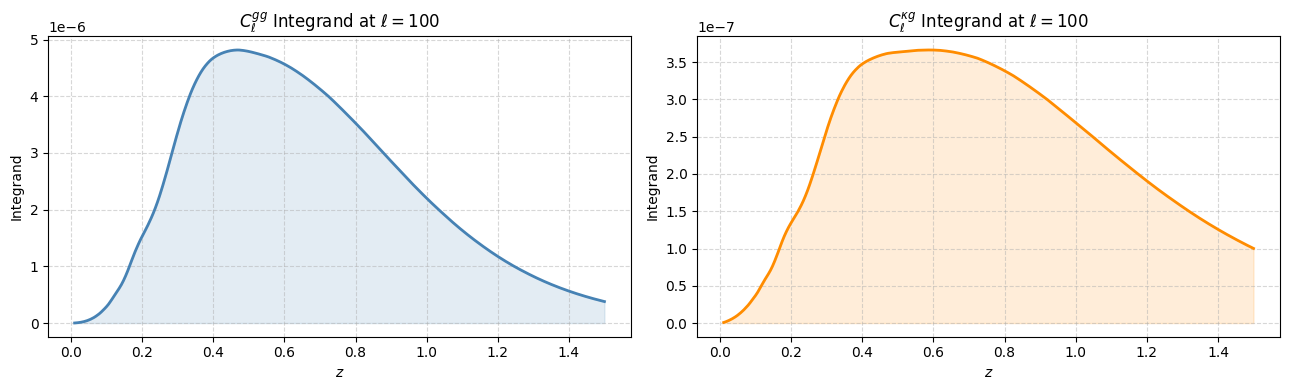

In [20]:
def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0, k_min=None, k_max=None
):
    """
    Galaxy x CMB lensing cross-spectrum C_ell^{kappa g} via Limber approximation.
    Bianchini et al. (2015) Eq. (7).
    """
    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "Ckg") if k_min else k_vals
        try:
            P_kz = np.exp([pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))])
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wkappa_vals * Wg_vals) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl

# ── Immediate spot-check: plot integrand at ell=100 ───────────────────────────
intgd_kg  = (H_vals / Config.c) * (Wkappa_vals * Wg_vals) * P_spot / (chi_vals ** 2)
Cl_kg_spot = simpson(intgd_kg, z_grid)
print(f"C_ell^{{kg}} spot-check at ell=100: {Cl_kg_spot:.4e}")
assert Cl_kg_spot > 0, "C_ell^{kappa g} must be positive"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(z_grid, intgd_gg, 'steelblue', lw=2)
axes[0].fill_between(z_grid, intgd_gg, alpha=0.15, color='steelblue')
axes[0].set(xlabel='$z$', ylabel='Integrand', title=r'$C_\ell^{gg}$ Integrand at $\ell=100$')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(z_grid, intgd_kg, 'darkorange', lw=2)
axes[1].fill_between(z_grid, intgd_kg, alpha=0.15, color='darkorange')
axes[1].set(xlabel='$z$', ylabel='Integrand', title=r'$C_\ell^{\kappa g}$ Integrand at $\ell=100$')
axes[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()


## 7. Compute All Angular Power Spectra

We now evaluate the Limber integrals across the full multipole range $\ell \in [10, 2000]$ for:
1. **GR** — using the BACCO interpolator grid.
2. **f(R)** with $\log_{10}|f_{R0}| = -4, -5, -6$ — using the EMANTIS-boosted grids.

Each spectrum is printed and plotted immediately after computation so the results can be inspected incrementally without waiting for all models to finish.

**Expected behaviour:**
- Both $C_\ell^{gg}$ and $C_\ell^{\kappa g}$ should be positive and broadly decreasing with $\ell$ (more power at large scales).
- f(R) spectra should lie above the GR baseline at all $\ell$, with the excess growing toward smaller scales (larger $\ell$) because the fifth force is more effective on small scales.
- Stronger modifications (smaller $\log_{10}|f_{R0}|$) should produce larger boosts.


In [21]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
print(f"ell grid: {ell.min():.0f} – {ell.max():.0f}  ({len(ell)} points, log-spaced)")


ell grid: 10 – 2000  (50 points, log-spaced)


### 7.1 GR Galaxy Auto-Spectrum $C_\ell^{gg}$

Computing GR C_ell^{gg} …
  Range : [6.831e-08, 9.193e-06]
  At ell=10  : 9.1927e-06
  At ell~100 : 3.7535e-06
  At ell=2000: 6.8308e-08


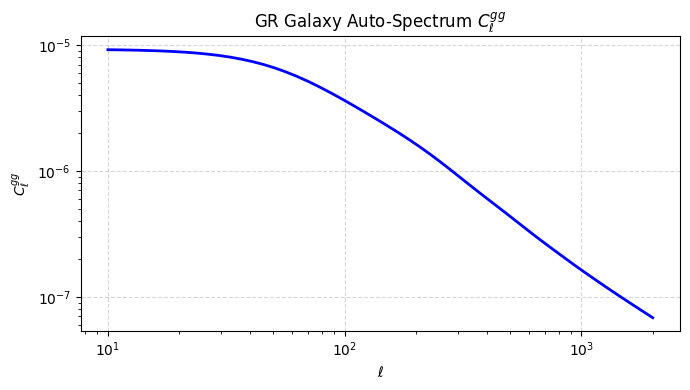

In [22]:
# ── GR C_ell^{gg} ──────────────────────────────────────────────────────────────
print("Computing GR C_ell^{gg} …")
Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr_z, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)
assert np.all(Cl_gg_gr > 0), "GR C_ell^gg must be positive at all ell"
print(f"  Range : [{Cl_gg_gr.min():.3e}, {Cl_gg_gr.max():.3e}]")
print(f"  At ell=10  : {Cl_gg_gr[0]:.4e}")
print(f"  At ell~100 : {Cl_gg_gr[np.argmin(np.abs(ell-100))]:.4e}")
print(f"  At ell=2000: {Cl_gg_gr[-1]:.4e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ell, Cl_gg_gr, 'b-', lw=2)
ax.set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
       title='GR Galaxy Auto-Spectrum $C_\ell^{gg}$')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 7.2 GR CMB Lensing × Galaxy Cross-Spectrum $C_\ell^{\kappa g}$

The cross-spectrum is generally smaller in amplitude than the auto-spectrum because $W^\kappa$ and $W^g$ have imperfect overlap — only the redshift range where both kernels are simultaneously non-zero contributes to the integral.


Computing GR C_ell^{kappa g} …
  Range : [6.492e-09, 8.379e-07]
  At ell=10  : 8.3793e-07
  At ell~100 : 3.6497e-07
  At ell=2000: 6.4918e-09


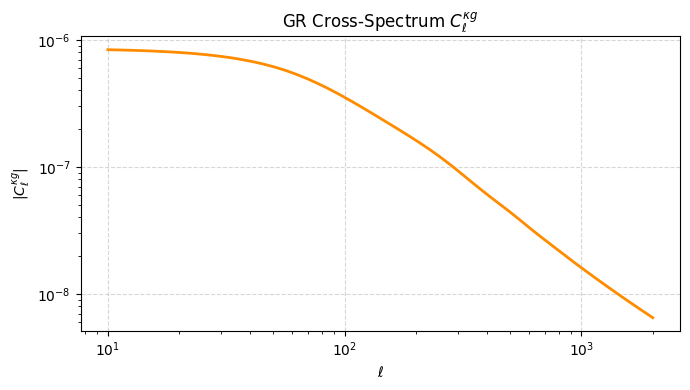

In [23]:
# ── GR C_ell^{kappa g} ─────────────────────────────────────────────────────────
print("Computing GR C_ell^{kappa g} …")
Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr_z, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)
assert np.all(Cl_kg_gr > 0), "GR C_ell^{kappa g} must be positive at all ell"
print(f"  Range : [{Cl_kg_gr.min():.3e}, {Cl_kg_gr.max():.3e}]")
print(f"  At ell=10  : {Cl_kg_gr[0]:.4e}")
print(f"  At ell~100 : {Cl_kg_gr[np.argmin(np.abs(ell-100))]:.4e}")
print(f"  At ell=2000: {Cl_kg_gr[-1]:.4e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ell, Cl_kg_gr, 'darkorange', lw=2)
ax.set(xlabel=r'$\ell$', ylabel=r'$|C_\ell^{\kappa g}|$',
       title='GR Cross-Spectrum $C_\ell^{\kappa g}$')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 7.3 f(R) Spectra vs GR

For each f(R) model, both spectra are computed and immediately compared to the GR baseline. The ratio $C_\ell^{f(R)} / C_\ell^{GR}$ is also printed to give a quantitative sense of the deviation at each scale.

The enhancement is scale-dependent: at large scales ($\ell \lesssim 100$) the fifth force is screened by the Compton wavelength of the scalaron, so the boost is small. At small scales ($\ell \gtrsim 500$) the boost grows, potentially reaching 10–40% for the strongest model ($\log_{10}|f_{R0}| = -4$).


Computing f(R) spectra for log10|fR0| = -4 …
  C_ell^gg  ratio (fR/GR): min=1.0008, max=1.3027
  C_ell^kg  ratio (fR/GR): min=1.0016, max=1.2836


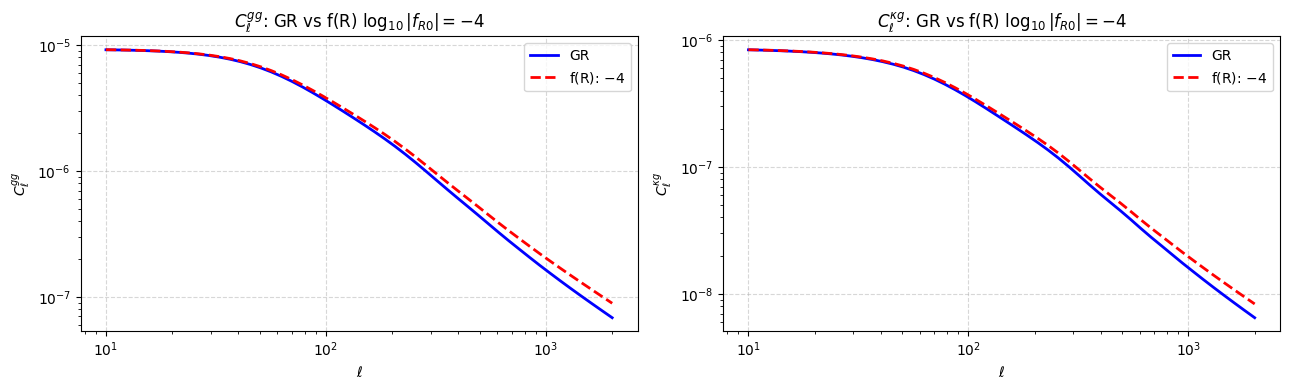

Computing f(R) spectra for log10|fR0| = -5 …
  C_ell^gg  ratio (fR/GR): min=1.0001, max=1.1050
  C_ell^kg  ratio (fR/GR): min=1.0002, max=1.0966


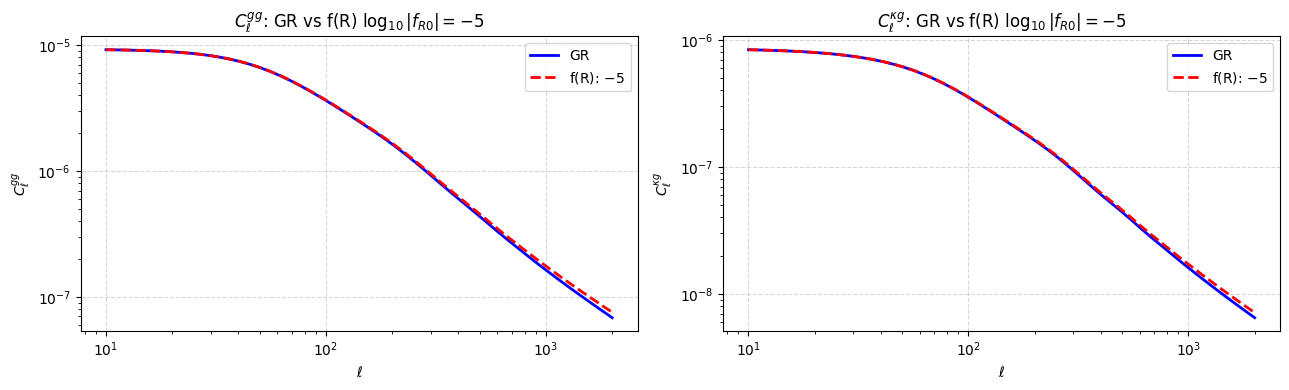

Computing f(R) spectra for log10|fR0| = -6 …
  C_ell^gg  ratio (fR/GR): min=1.0002, max=1.0144
  C_ell^kg  ratio (fR/GR): min=1.0003, max=1.0135


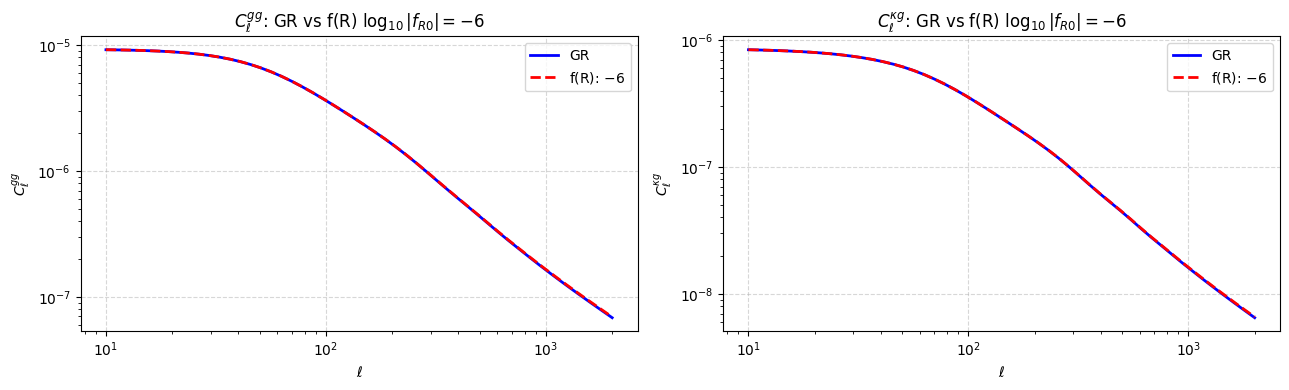


All f(R) spectra computed.


In [24]:
# ── f(R) spectra — one fR value at a time ──────────────────────────────────────
fr_results = {"gg": {}, "kg": {}}

for fv in Config.FR_VALUES:
    print(f"Computing f(R) spectra for log10|fR0| = -{fv} …")

    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, fr_pk_interps[fv], z_grid, Wg_vals,
        chi_vals, H_vals, D_vals, D0, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, fr_pk_interps[fv], z_grid, Wg_vals,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    fr_results["gg"][fv] = Cl_gg_fr
    fr_results["kg"][fv] = Cl_kg_fr

    ratio_gg = Cl_gg_fr / Cl_gg_gr
    ratio_kg = Cl_kg_fr / Cl_kg_gr
    print(f"  C_ell^gg  ratio (fR/GR): min={ratio_gg.min():.4f}, max={ratio_gg.max():.4f}")
    print(f"  C_ell^kg  ratio (fR/GR): min={ratio_kg.min():.4f}, max={ratio_kg.max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].loglog(ell, Cl_gg_gr, 'b-',  lw=2, label='GR')
    axes[0].loglog(ell, Cl_gg_fr, 'r--', lw=2, label=rf'f(R): $-{fv}$')
    axes[0].set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
                title=rf'$C_\ell^{{gg}}$: GR vs f(R) $\log_{{10}}|f_{{R0}}|=-{fv}$')
    axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.5)

    axes[1].loglog(ell, Cl_kg_gr, 'b-',  lw=2, label='GR')
    axes[1].loglog(ell, Cl_kg_fr, 'r--', lw=2, label=rf'f(R): $-{fv}$')
    axes[1].set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{\kappa g}$',
                title=rf'$C_\ell^{{\kappa g}}$: GR vs f(R) $\log_{{10}}|f_{{R0}}|=-{fv}$')
    axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)
    plt.tight_layout(); plt.show()

print("\nAll f(R) spectra computed.")


## 8. Tabular Summary at Selected Multipoles

The table below collects $C_\ell$ values at six representative multipoles for all gravity models. Use it to:

- Compare GR and f(R) amplitudes at a glance.
- Check that the f(R)/GR ratio increases from low to high $\ell$ (scale-dependent enhancement).
- Verify that the three f(R) models are ordered $|f_{R0}|=-4 > -5 > -6$ at every multipole.


In [25]:
try:
    import pandas as pd
    _pandas = True
except ImportError:
    _pandas = False

ell_show = [10, 50, 100, 500, 1000, 2000]
ell_idx  = [np.argmin(np.abs(ell - lv)) for lv in ell_show]

rows = []
for idx in ell_idx:
    row = {
        "ell":      f"{ell[idx]:.0f}",
        "Cl_gg_GR": f"{Cl_gg_gr[idx]:.3e}",
        "Cl_kg_GR": f"{Cl_kg_gr[idx]:.3e}",
    }
    for fv in Config.FR_VALUES:
        row[f"Cl_gg_fR{fv}"] = f"{fr_results['gg'][fv][idx]:.3e}"
        row[f"Cl_kg_fR{fv}"] = f"{fr_results['kg'][fv][idx]:.3e}"
    rows.append(row)

if _pandas:
    df = pd.DataFrame(rows).set_index("ell")
    display(df)
else:
    header = list(rows[0].keys())
    print("  ".join(f"{h:>14}" for h in header))
    print("-" * (16 * len(header)))
    for r in rows:
        print("  ".join(f"{r[h]:>14}" for h in header))


,Cl_gg_GR,Cl_kg_GR,Cl_gg_fR4,Cl_kg_fR4,Cl_gg_fR5,Cl_kg_fR5,Cl_gg_fR6,Cl_kg_fR6
ell,,,,,,,,
10,9.193e-06,8.379e-07,9.200e-06,8.393e-07,9.193e-06,8.381e-07,9.195e-06,8.382e-07
51,6.589e-06,6.118e-07,6.724e-06,6.234e-07,6.604e-06,6.132e-07,6.593e-06,6.123e-07
97,3.754e-06,3.650e-07,3.938e-06,3.804e-07,3.780e-06,3.673e-07,3.757e-06,3.653e-07
490,4.481e-07,4.529e-08,5.230e-07,5.200e-08,4.677e-07,4.700e-08,4.506e-07,4.551e-08
1045,1.541e-07,1.510e-08,1.924e-07,1.852e-08,1.659e-07,1.614e-08,1.557e-07,1.524e-08
2000,6.831e-08,6.492e-09,8.899e-08,8.333e-09,7.548e-08,7.119e-09,6.929e-08,6.579e-09


## 9. Full Results — All Spectra and f(R)/GR Ratios

The 2×2 summary figure shows:

- **(Top row)**: absolute spectra $C_\ell^{gg}$ and $C_\ell^{\kappa g}$ for GR and all three f(R) models on a log-log scale. The GR curve acts as the baseline; f(R) curves lie systematically above it.

- **(Bottom row)**: the ratios $C_\ell^{f(R)} / C_\ell^{GR}$ for each model on a semi-log scale. A ratio of 1 (black dashed line) means no deviation from GR. The scale-dependent rise of the ratios toward high $\ell$ directly reflects the scale-dependent enhancement of the matter power spectrum by the fifth force.

The ratio plots are the most direct observational diagnostic of modified gravity: if future surveys can measure $C_\ell^{gg}$ or $C_\ell^{\kappa g}$ with sufficient precision, deviations of the ratio from 1 would constitute evidence for (or constraints on) f(R) gravity.


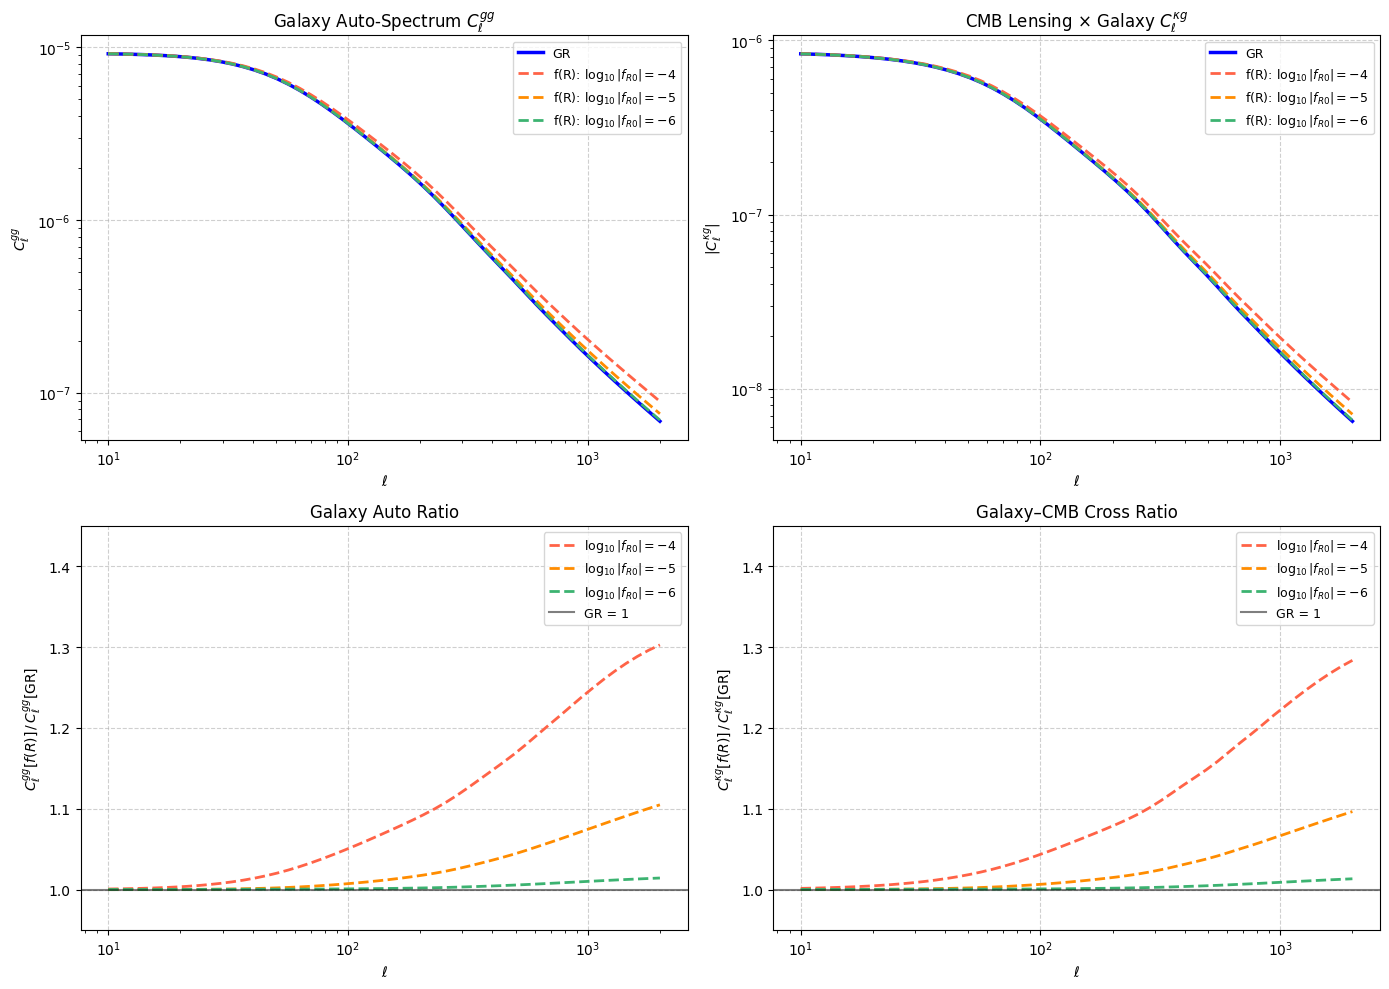

In [26]:
colors = ['tomato', 'darkorange', 'mediumseagreen']
fig = plt.figure(figsize=Config.FIGURE_SIZE)

# ── C_ell^{gg} ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.loglog(ell, Cl_gg_gr, 'b-', lw=2.5, label='GR')
for fv, col in zip(Config.FR_VALUES, colors):
    ax1.loglog(ell, fr_results["gg"][fv], '--', lw=2, color=col,
               label=rf'f(R): $\log_{{10}}|f_{{R0}}|=-{fv}$')
ax1.set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
        title=r'Galaxy Auto-Spectrum $C_\ell^{gg}$')
ax1.legend(fontsize=9); ax1.grid(True, ls='--', alpha=0.6)

# ── C_ell^{kappa g} ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
ax2.loglog(ell, np.abs(Cl_kg_gr), 'b-', lw=2.5, label='GR')
for fv, col in zip(Config.FR_VALUES, colors):
    ax2.loglog(ell, np.abs(fr_results["kg"][fv]), '--', lw=2, color=col,
               label=rf'f(R): $\log_{{10}}|f_{{R0}}|=-{fv}$')
ax2.set(xlabel=r'$\ell$', ylabel=r'$|C_\ell^{\kappa g}|$',
        title=r'CMB Lensing $\times$ Galaxy $C_\ell^{\kappa g}$')
ax2.legend(fontsize=9); ax2.grid(True, ls='--', alpha=0.6)

# ── Ratio C_ell^{gg} ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
for fv, col in zip(Config.FR_VALUES, colors):
    ax3.semilogx(ell, fr_results["gg"][fv] / Cl_gg_gr, '--', lw=2, color=col,
                 label=rf'$\log_{{10}}|f_{{R0}}|=-{fv}$')
ax3.axhline(1.0, color='k', lw=1.5, alpha=0.5, label='GR = 1')
ax3.set(xlabel=r'$\ell$',
        ylabel=r'$C_\ell^{gg}[f(R)]\,/\,C_\ell^{gg}[\mathrm{GR}]$',
        title='Galaxy Auto Ratio', ylim=[0.95, 1.45])
ax3.legend(fontsize=9); ax3.grid(True, ls='--', alpha=0.6)

# ── Ratio C_ell^{kappa g} ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
for fv, col in zip(Config.FR_VALUES, colors):
    ax4.semilogx(ell, fr_results["kg"][fv] / Cl_kg_gr, '--', lw=2, color=col,
                 label=rf'$\log_{{10}}|f_{{R0}}|=-{fv}$')
ax4.axhline(1.0, color='k', lw=1.5, alpha=0.5, label='GR = 1')
ax4.set(xlabel=r'$\ell$',
        ylabel=r'$C_\ell^{\kappa g}[f(R)]\,/\,C_\ell^{\kappa g}[\mathrm{GR}]$',
        title='Galaxy–CMB Cross Ratio', ylim=[0.95, 1.45])
ax4.legend(fontsize=9); ax4.grid(True, ls='--', alpha=0.6)

plt.tight_layout(); plt.show()


## 10. Validation — Comprehensive Assertions & Sanity Checks

This section re-tests all outputs produced above against a set of physical and numerical consistency requirements. The checks are grouped by category:

**Cosmological functions**  
Basic boundary conditions ($H(0) = H_0$, $D(0) = 1$, $\chi(0) = 0$) and global monotonicity ($\chi$ increasing, $D$ decreasing).

**Galaxy distribution**  
Correct normalisation $\int n(z)\,dz = 1$ and non-negativity everywhere.

**Lensing kernels**  
Both $W^\kappa$ and $W^g$ must be non-negative, with a positive peak.

**Power spectrum interpolators**  
Round-trip accuracy of the log-log spline, and correct number of slices in each interpolator grid.

**GR angular power spectra**  
Positivity, physical amplitude bounds, correct array length, and broad decrease with $\ell$ (large-scale excess).

**f(R) angular power spectra**  
The ratio $C_\ell^{f(R)}/C_\ell^{GR}$ must be $\geq 1$ at every $\ell$ (f(R) always enhances power, never suppresses it in this regime). All spectra must be positive and correctly sized.

**f(R) physical ordering**  
Stronger modification ($\log_{10}|f_{R0}| = -4$) must produce a larger boost than weaker modification ($\log_{10}|f_{R0}| = -6$) at mid-range $\ell$.

**Multipole grid**  
Correct number of points, correct range, and monotonic ordering.


In [27]:
print("=" * 65)
print("  VALIDATION SUITE")
print("=" * 65)
failures = []

def check(condition, msg):
    if condition:
        print(f"  OK   {msg}")
    else:
        failures.append(msg)
        print(f"  FAIL {msg}")

# ── Cosmology ─────────────────────────────────────────────────────────────────
print("\n[Cosmological Functions]")
check(abs(hubble_function(0, H0, Om_m, Om_lambda) - H0) < 1e-6,
      f"H(z=0) == H0 = {H0:.2f} km/s/Mpc")
check(abs(growth_factor_D(1e-5, H0, Om_m, Om_lambda) - 1.0) < 0.005,
      "D(z->0) = 1.0 (normalised)")
check(np.all(np.diff(growth_factor_D(np.linspace(0.01, 3, 50), H0, Om_m, Om_lambda)) <= 0),
      "D(z) monotonically decreasing")
check(np.all(np.diff(comoving_distance_proper(np.linspace(0.01, 3, 50), H0, Om_m, Om_lambda)) > 0),
      "chi(z) monotonically increasing")
check(abs(comoving_distance_proper(1e-5, H0, Om_m, Om_lambda)) < 1.0,
      "chi(z->0) ~ 0 Mpc")
check(abs(compute_Omega_z(0, H0, Om_m, Om_lambda) - Om_m) < 1e-6,
      f"Omega_m(z=0) = {Om_m}")
check(abs(compute_lambda_z(0, H0, Om_m, Om_lambda) - Om_lambda) < 1e-6,
      f"Omega_Lambda(z=0) = {Om_lambda:.4f}")
check(abs(bias_function(1e-5, H0, Om_m, Om_lambda, b0=Config.BIAS_B0) - Config.BIAS_B0) < 0.01,
      f"b(z->0) = b0 = {Config.BIAS_B0}")

# ── Galaxy distribution ───────────────────────────────────────────────────────
print("\n[Galaxy Distribution]")
norm = simpson(dNdz, z_grid)
check(abs(norm - 1.0) < 1e-4,  f"int n(z) dz = 1  (got {norm:.6f})")
check(np.all(dNdz >= 0),        "n(z) >= 0 everywhere")
check(dNdz[0] >= 0,             "n(z_min) >= 0")
check(dNdz[-1] >= 0,            "n(z_max) >= 0")

# ── Kernels ───────────────────────────────────────────────────────────────────
print("\n[Lensing Kernels]")
check(np.all(Wkappa_vals >= 0),  "W_kappa(z) >= 0 everywhere")
check(Wkappa_vals.max() > 0,     "W_kappa has a positive peak")
check(Wg_vals.max() > 0,         "W_g has a positive peak")

# ── Power spectrum interpolators ──────────────────────────────────────────────
print("\n[Power Spectrum Interpolators]")
k_interior = k[5:-5:10]
pk_orig     = pk_z0[5:-5:10]
pk_recon    = np.exp(create_power_spectrum_interpolator(k, pk_z0)(np.log(k_interior)))
max_rel_err = np.max(np.abs(pk_recon - pk_orig) / pk_orig)
check(max_rel_err < 1e-3, f"Interpolator round-trip max rel. error = {max_rel_err:.2e} < 0.1%")
check(len(pk_interp_gr_z) == Config.N_Z, f"GR interpolator grid has {Config.N_Z} slices")
for fv in Config.FR_VALUES:
    check(len(fr_pk_interps[fv]) == Config.N_Z,
          f"f(R)-{fv} interpolator grid has {Config.N_Z} slices")

# ── GR spectra ────────────────────────────────────────────────────────────────
print("\n[GR Angular Power Spectra]")
check(np.all(Cl_gg_gr > 0),      "C_ell^{gg} [GR] > 0 for all ell")
check(np.all(Cl_kg_gr > 0),      "C_ell^{kappa g} [GR] > 0 for all ell")
check(np.all(Cl_gg_gr < 1e3),    "C_ell^{gg} [GR] < 1e3 (physical scale check)")
check(np.all(Cl_kg_gr < 1e3),    "C_ell^{kappa g} [GR] < 1e3")
check(len(Cl_gg_gr) == Config.N_ELL, f"C_ell^gg has {Config.N_ELL} multipoles")
check(len(Cl_kg_gr) == Config.N_ELL, f"C_ell^kg has {Config.N_ELL} multipoles")
n_half = Config.N_ELL // 2
check(np.median(Cl_gg_gr[:n_half]) > np.median(Cl_gg_gr[n_half:]),
      "C_ell^{gg} [GR] broadly decreasing with ell")
check(np.median(Cl_kg_gr[:n_half]) > np.median(Cl_kg_gr[n_half:]),
      "C_ell^{kappa g} [GR] broadly decreasing with ell")

# ── f(R) spectra ──────────────────────────────────────────────────────────────
print("\n[f(R) Angular Power Spectra]")
for fv in Config.FR_VALUES:
    ratio_gg = fr_results["gg"][fv] / Cl_gg_gr
    ratio_kg = fr_results["kg"][fv] / Cl_kg_gr
    check(np.all(ratio_gg >= 1.0 - 1e-3),
          f"C_ell^gg  ratio >= 1 for log|fR0|=-{fv}  (min={ratio_gg.min():.4f})")
    check(np.all(ratio_kg >= 1.0 - 1e-3),
          f"C_ell^kg  ratio >= 1 for log|fR0|=-{fv}  (min={ratio_kg.min():.4f})")
    check(np.all(fr_results["gg"][fv] > 0), f"C_ell^gg  [fR{fv}] > 0 everywhere")
    check(np.all(fr_results["kg"][fv] > 0), f"C_ell^kg  [fR{fv}] > 0 everywhere")

# ── Ordering: stronger f(R) -> larger boost ───────────────────────────────────
print("\n[f(R) Physical Ordering]")
if len(Config.FR_VALUES) >= 2:
    fv_strong = min(Config.FR_VALUES)   # smaller log|fR0| = stronger modification
    fv_weak   = max(Config.FR_VALUES)
    mid       = Config.N_ELL // 2
    ratio_s   = fr_results["gg"][fv_strong][mid] / Cl_gg_gr[mid]
    ratio_w   = fr_results["gg"][fv_weak][mid]   / Cl_gg_gr[mid]
    check(ratio_s >= ratio_w,
          f"Stronger f(R) (log|fR0|=-{fv_strong}) boosts C_ell^gg more than "
          f"weaker (log|fR0|=-{fv_weak}): {ratio_s:.4f} >= {ratio_w:.4f}")

# ── ell grid ──────────────────────────────────────────────────────────────────
print("\n[Multipole Grid]")
check(len(ell) == Config.N_ELL,       f"ell grid has {Config.N_ELL} points")
check(ell[0]  >= Config.ELL_MIN - 1,  f"ell_min ~ {Config.ELL_MIN}")
check(ell[-1] <= Config.ELL_MAX + 1,  f"ell_max ~ {Config.ELL_MAX}")
check(np.all(np.diff(ell) > 0),        "ell grid is monotonically increasing")

# ── Final verdict ─────────────────────────────────────────────────────────────
print()
print("=" * 65)
if failures:
    print(f"  {len(failures)} check(s) FAILED:")
    for f in failures:
        print(f"    * {f}")
else:
    print("  ALL VALIDATION CHECKS PASSED")
    print()
    idx100 = np.argmin(np.abs(ell - 100))
    print(f"  GR C_ell^gg  @ ell~100 : {Cl_gg_gr[idx100]:.4e}")
    print(f"  GR C_ell^kg  @ ell~100 : {Cl_kg_gr[idx100]:.4e}")
    for fv in Config.FR_VALUES:
        rgg = fr_results['gg'][fv][idx100] / Cl_gg_gr[idx100]
        rkg = fr_results['kg'][fv][idx100] / Cl_kg_gr[idx100]
        print(f"  f(R) log|fR0|=-{fv}  "
              f"ratio C_gg={rgg:.4f},  ratio C_kg={rkg:.4f}")
print("=" * 65)


  VALIDATION SUITE

[Cosmological Functions]
  OK   H(z=0) == H0 = 67.00 km/s/Mpc
  OK   D(z->0) = 1.0 (normalised)
  OK   D(z) monotonically decreasing
  OK   chi(z) monotonically increasing
  OK   chi(z->0) ~ 0 Mpc
  OK   Omega_m(z=0) = 0.315
  OK   Omega_Lambda(z=0) = 0.6850
  OK   b(z->0) = b0 = 2.0

[Galaxy Distribution]
  OK   int n(z) dz = 1  (got 1.000000)
  OK   n(z) >= 0 everywhere
  OK   n(z_min) >= 0
  OK   n(z_max) >= 0

[Lensing Kernels]
  OK   W_kappa(z) >= 0 everywhere
  OK   W_kappa has a positive peak
  OK   W_g has a positive peak

[Power Spectrum Interpolators]
  OK   Interpolator round-trip max rel. error = 1.96e-15 < 0.1%
  OK   GR interpolator grid has 500 slices
  OK   f(R)-4 interpolator grid has 500 slices
  OK   f(R)-5 interpolator grid has 500 slices
  OK   f(R)-6 interpolator grid has 500 slices

[GR Angular Power Spectra]
  OK   C_ell^{gg} [GR] > 0 for all ell
  OK   C_ell^{kappa g} [GR] > 0 for all ell
  OK   C_ell^{gg} [GR] < 1e3 (physical scale check)
 